In [233]:
yields <- read.table("http://stat.ethz.ch/Teaching/Datasets/WBL/yields.dat",
header = FALSE)
t.yields <- ts(yields[, 1])

In [234]:
options(repr.plot.width = 14, repr.plot.height = 7, repr.plot.res = 200)

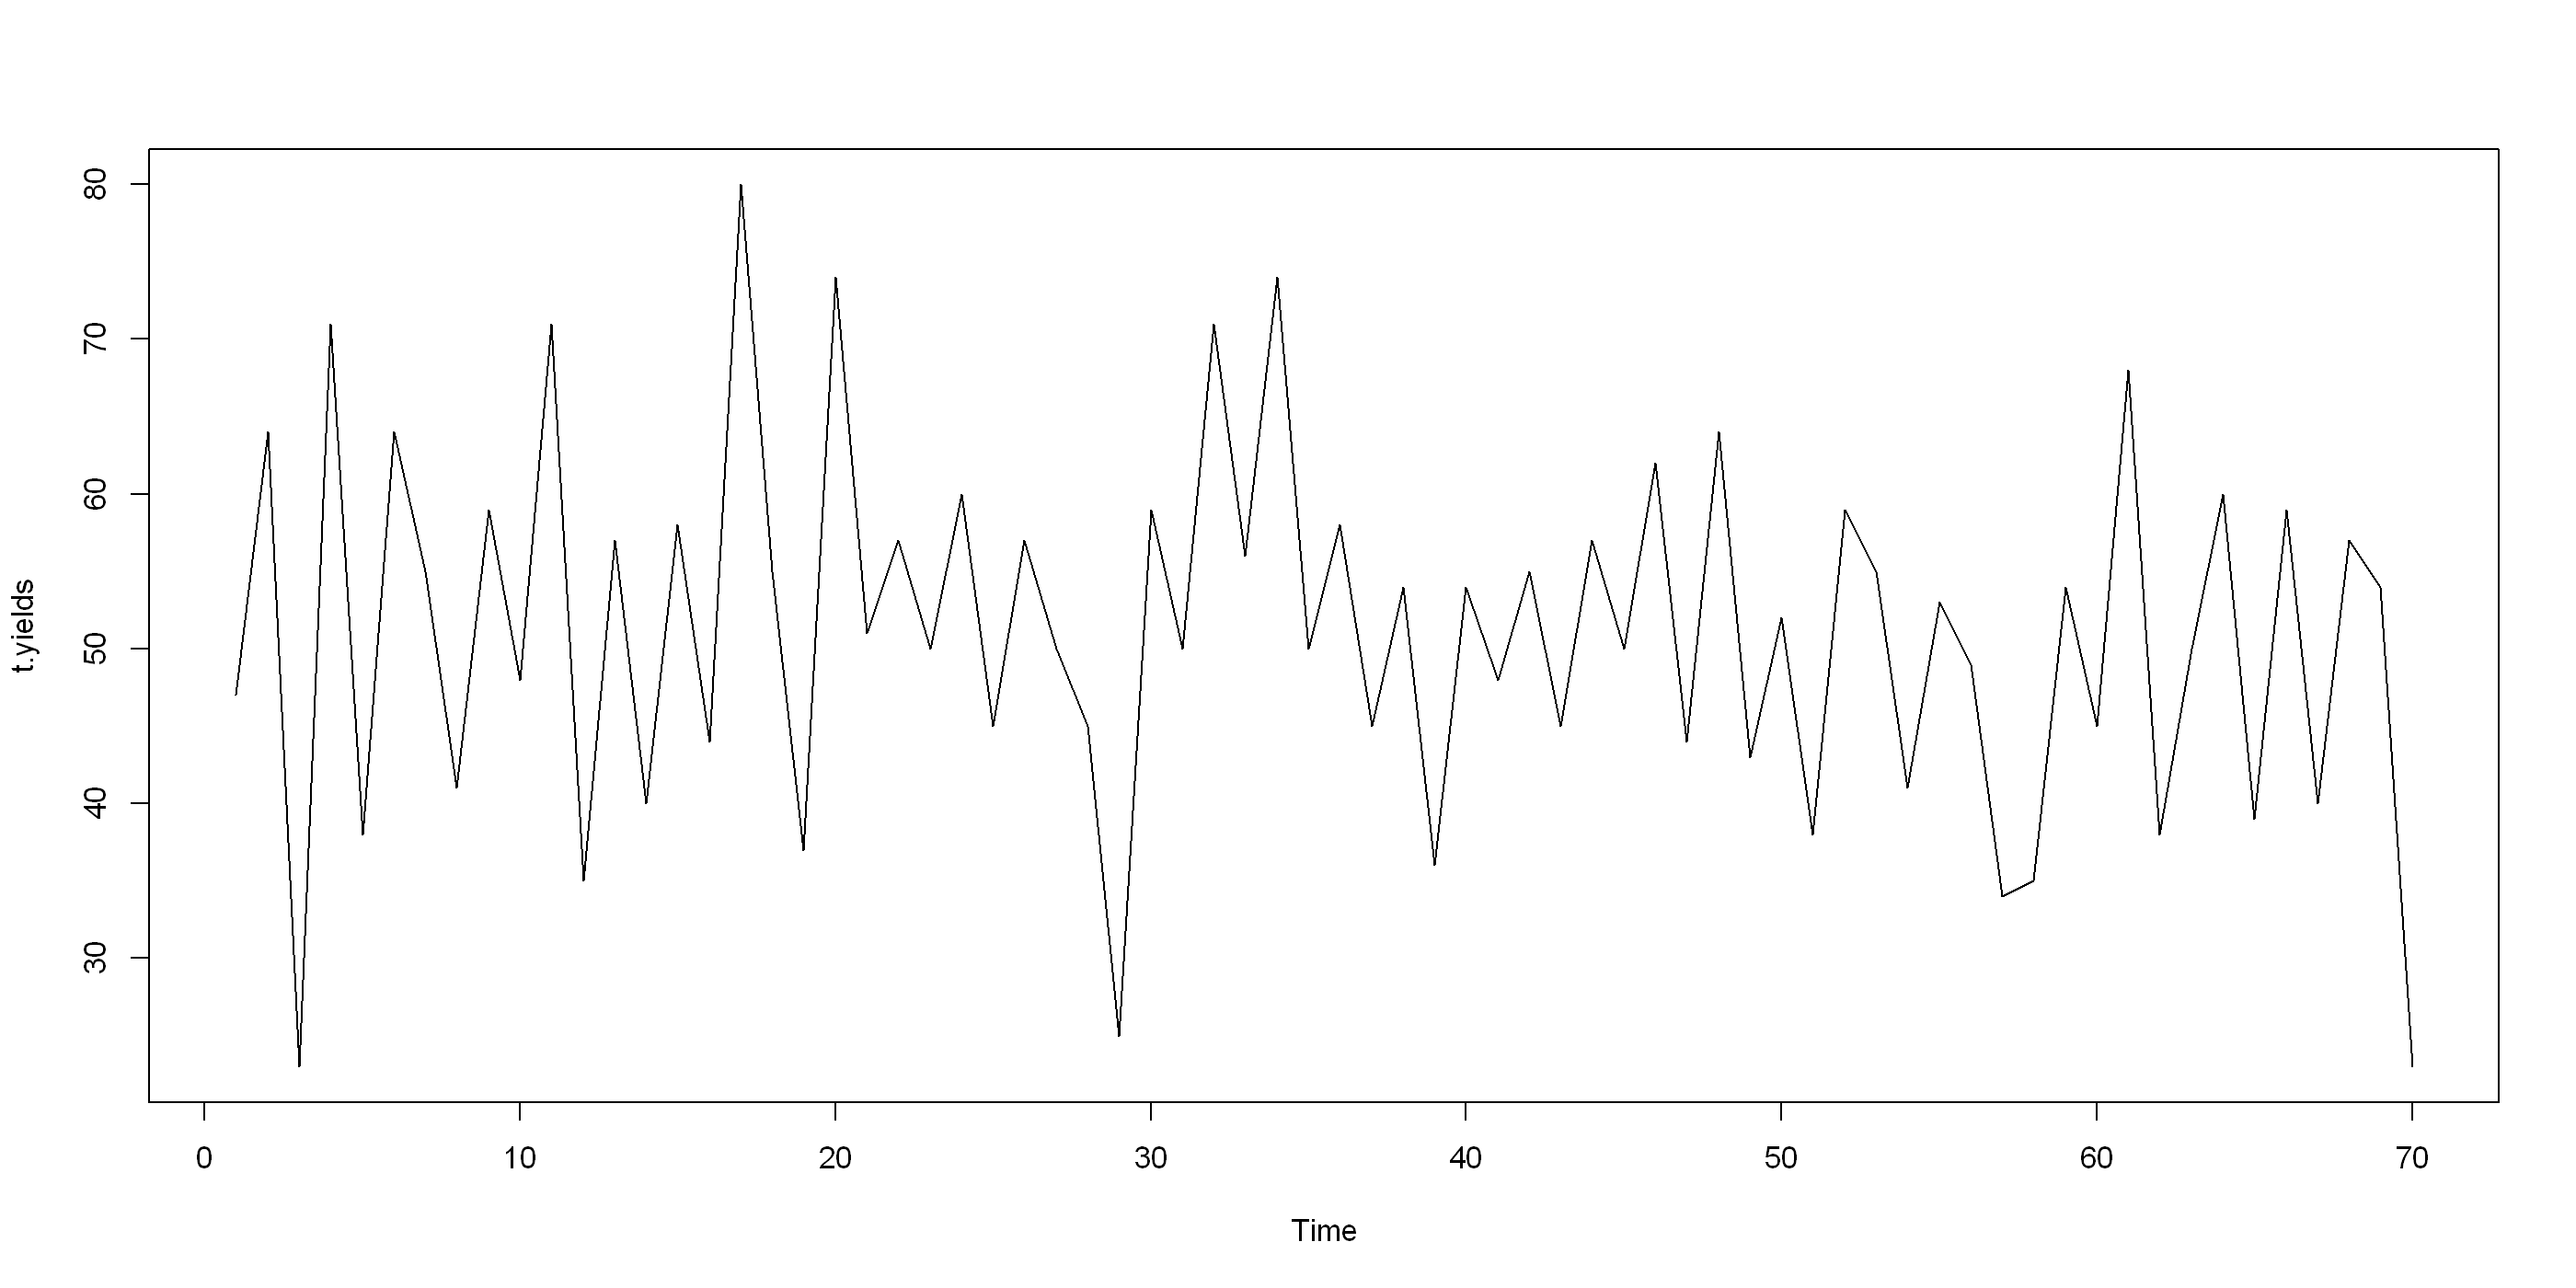

In [235]:
plot(t.yields)

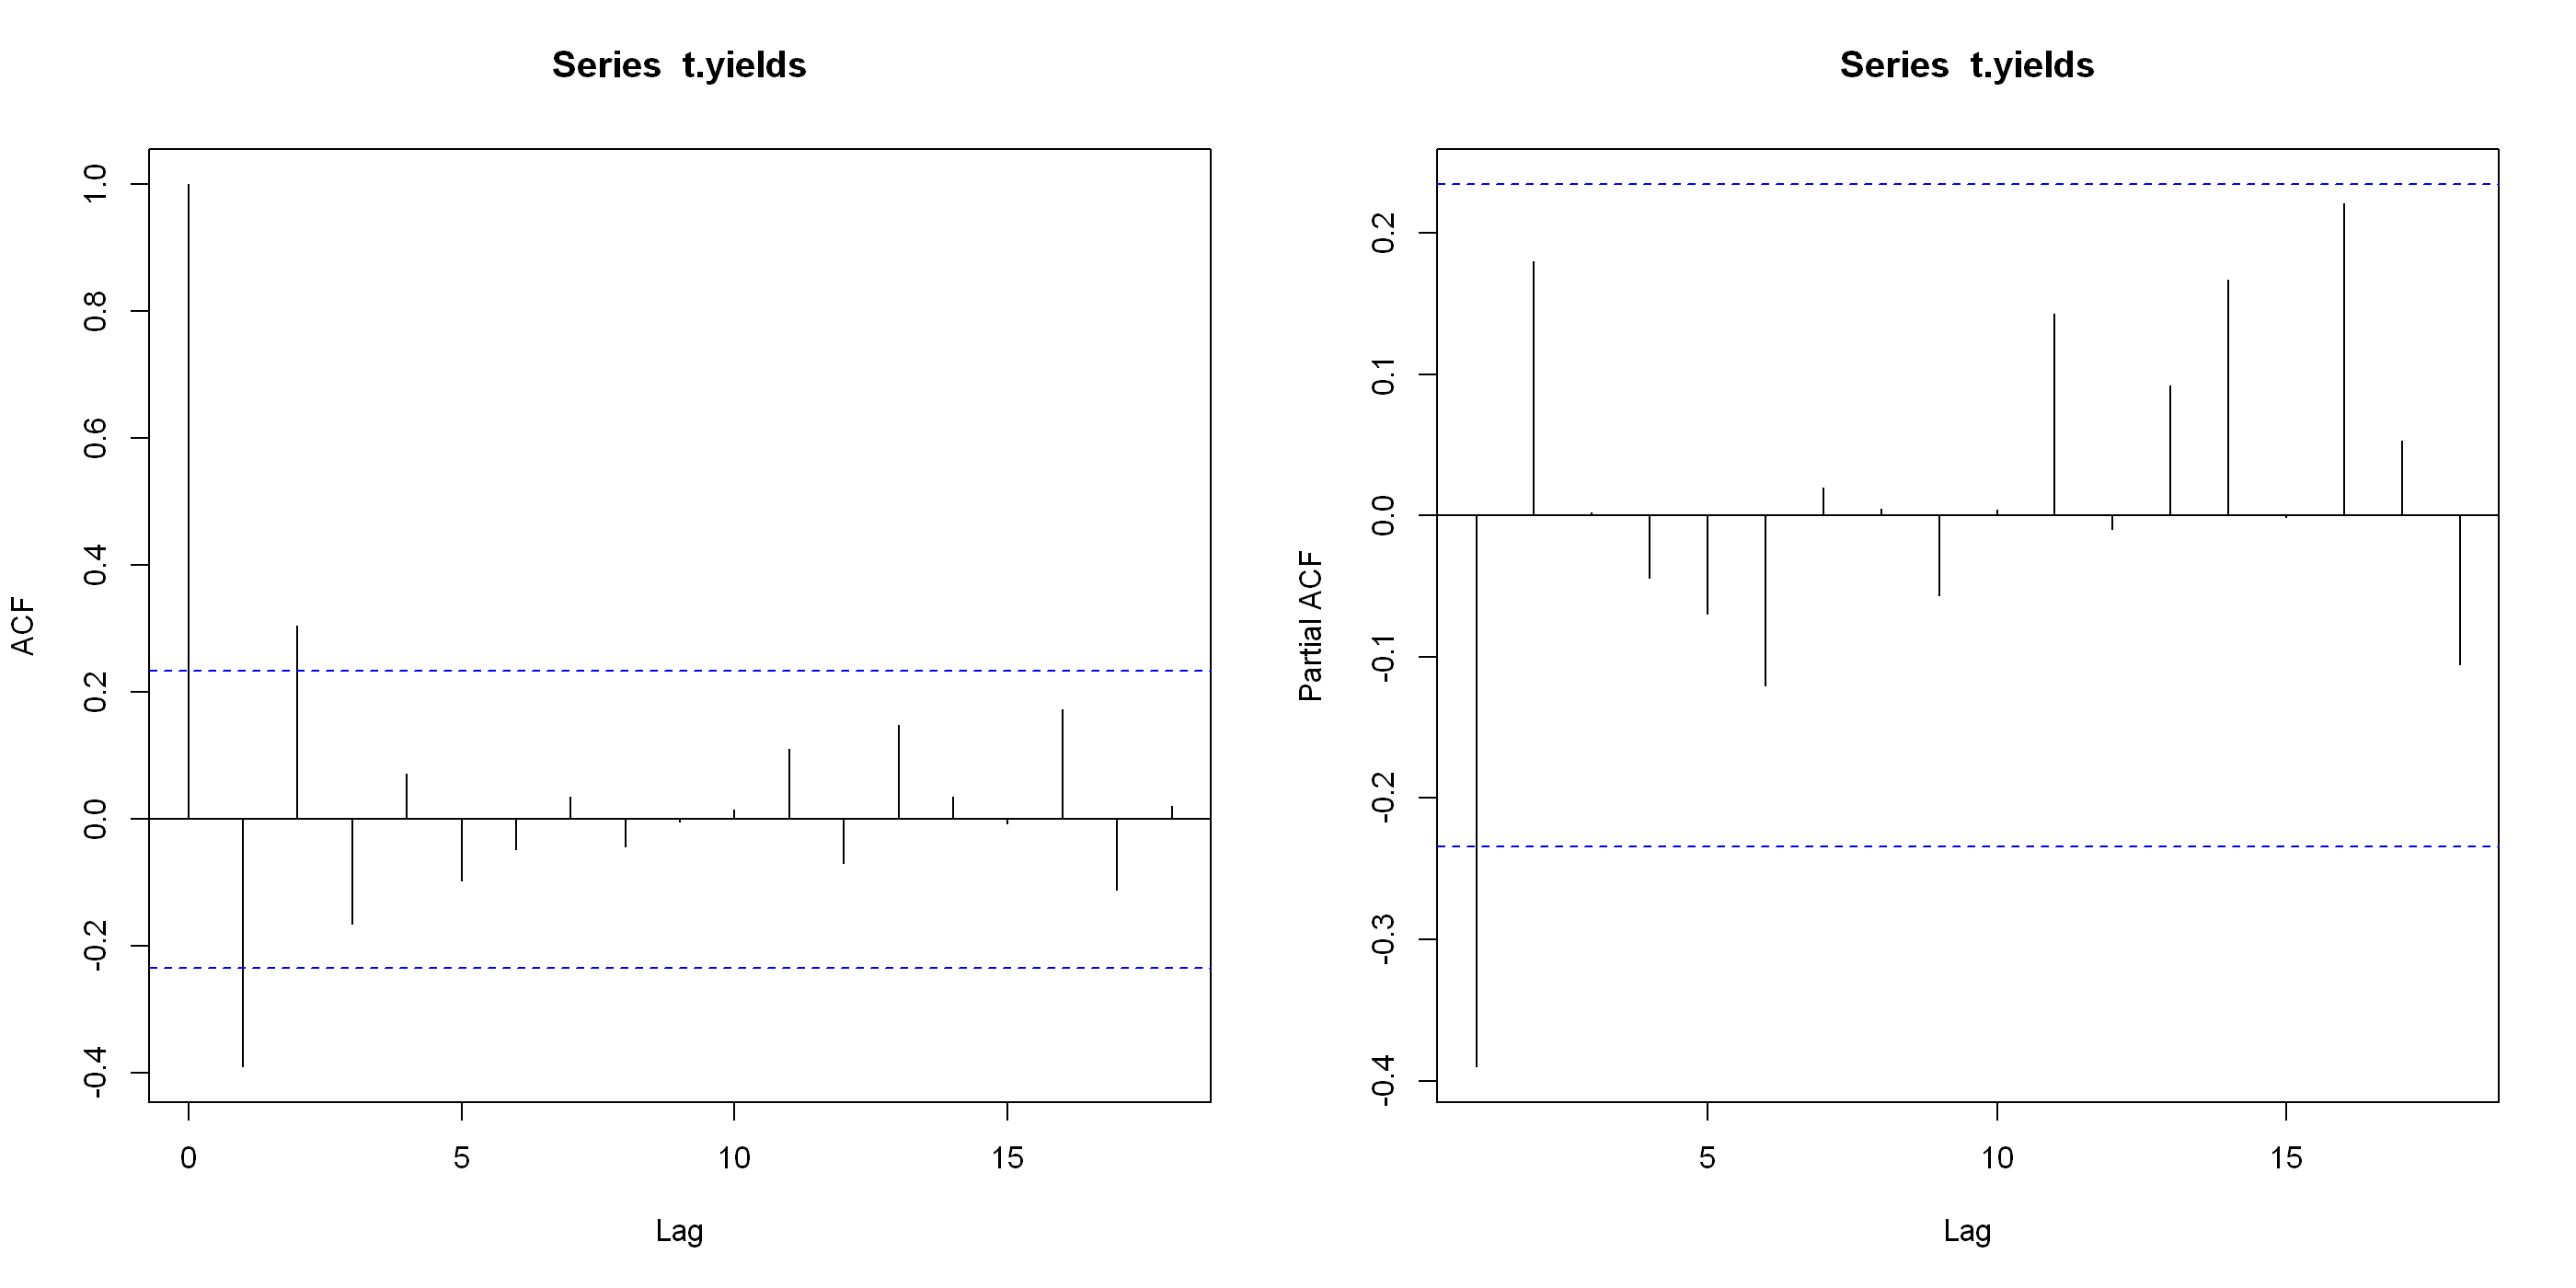

In [236]:
par(mfrow = c(1,2))
acf<-acf(t.yields)
pacf(t.yields)

In [237]:
alpha1 <- acf$acf[2]
cov <- acf(t.yields,type="covariance",plot=F)

In [238]:
mean(t.yields)


[1] 51.12857

In [239]:
var(t.yields)*(1-alpha1^2)*69/68

[1] 122.0345

In [240]:
r.yw <- ar(t.yields,method="yw",order.max = 1)
str(r.yw)

List of 15
 $ order       : int 1
 $ ar          : num -0.39
 $ var.pred    : num 122
 $ x.mean      : num 51.1
 $ aic         : Named num [1:2] 9.54 0
  ..- attr(*, "names")= chr [1:2] "0" "1"
 $ n.used      : int 70
 $ n.obs       : int 70
 $ order.max   : num 1
 $ partialacf  : num [1, 1, 1] -0.39
 $ resid       : Time-Series [1:70] from 1 to 70: NA 11.26 -23.11 8.9 -5.38 ...
 $ method      : chr "Yule-Walker"
 $ series      : chr "t.yields"
 $ frequency   : num 1
 $ call        : language ar(x = t.yields, order.max = 1, method = "yw")
 $ asy.var.coef: num [1, 1] 0.0125
 - attr(*, "class")= chr "ar"


In [241]:
r.burg <- ar(t.yields,method="burg",order.max=1)

In [242]:
alpha1 <- r.burg$ar

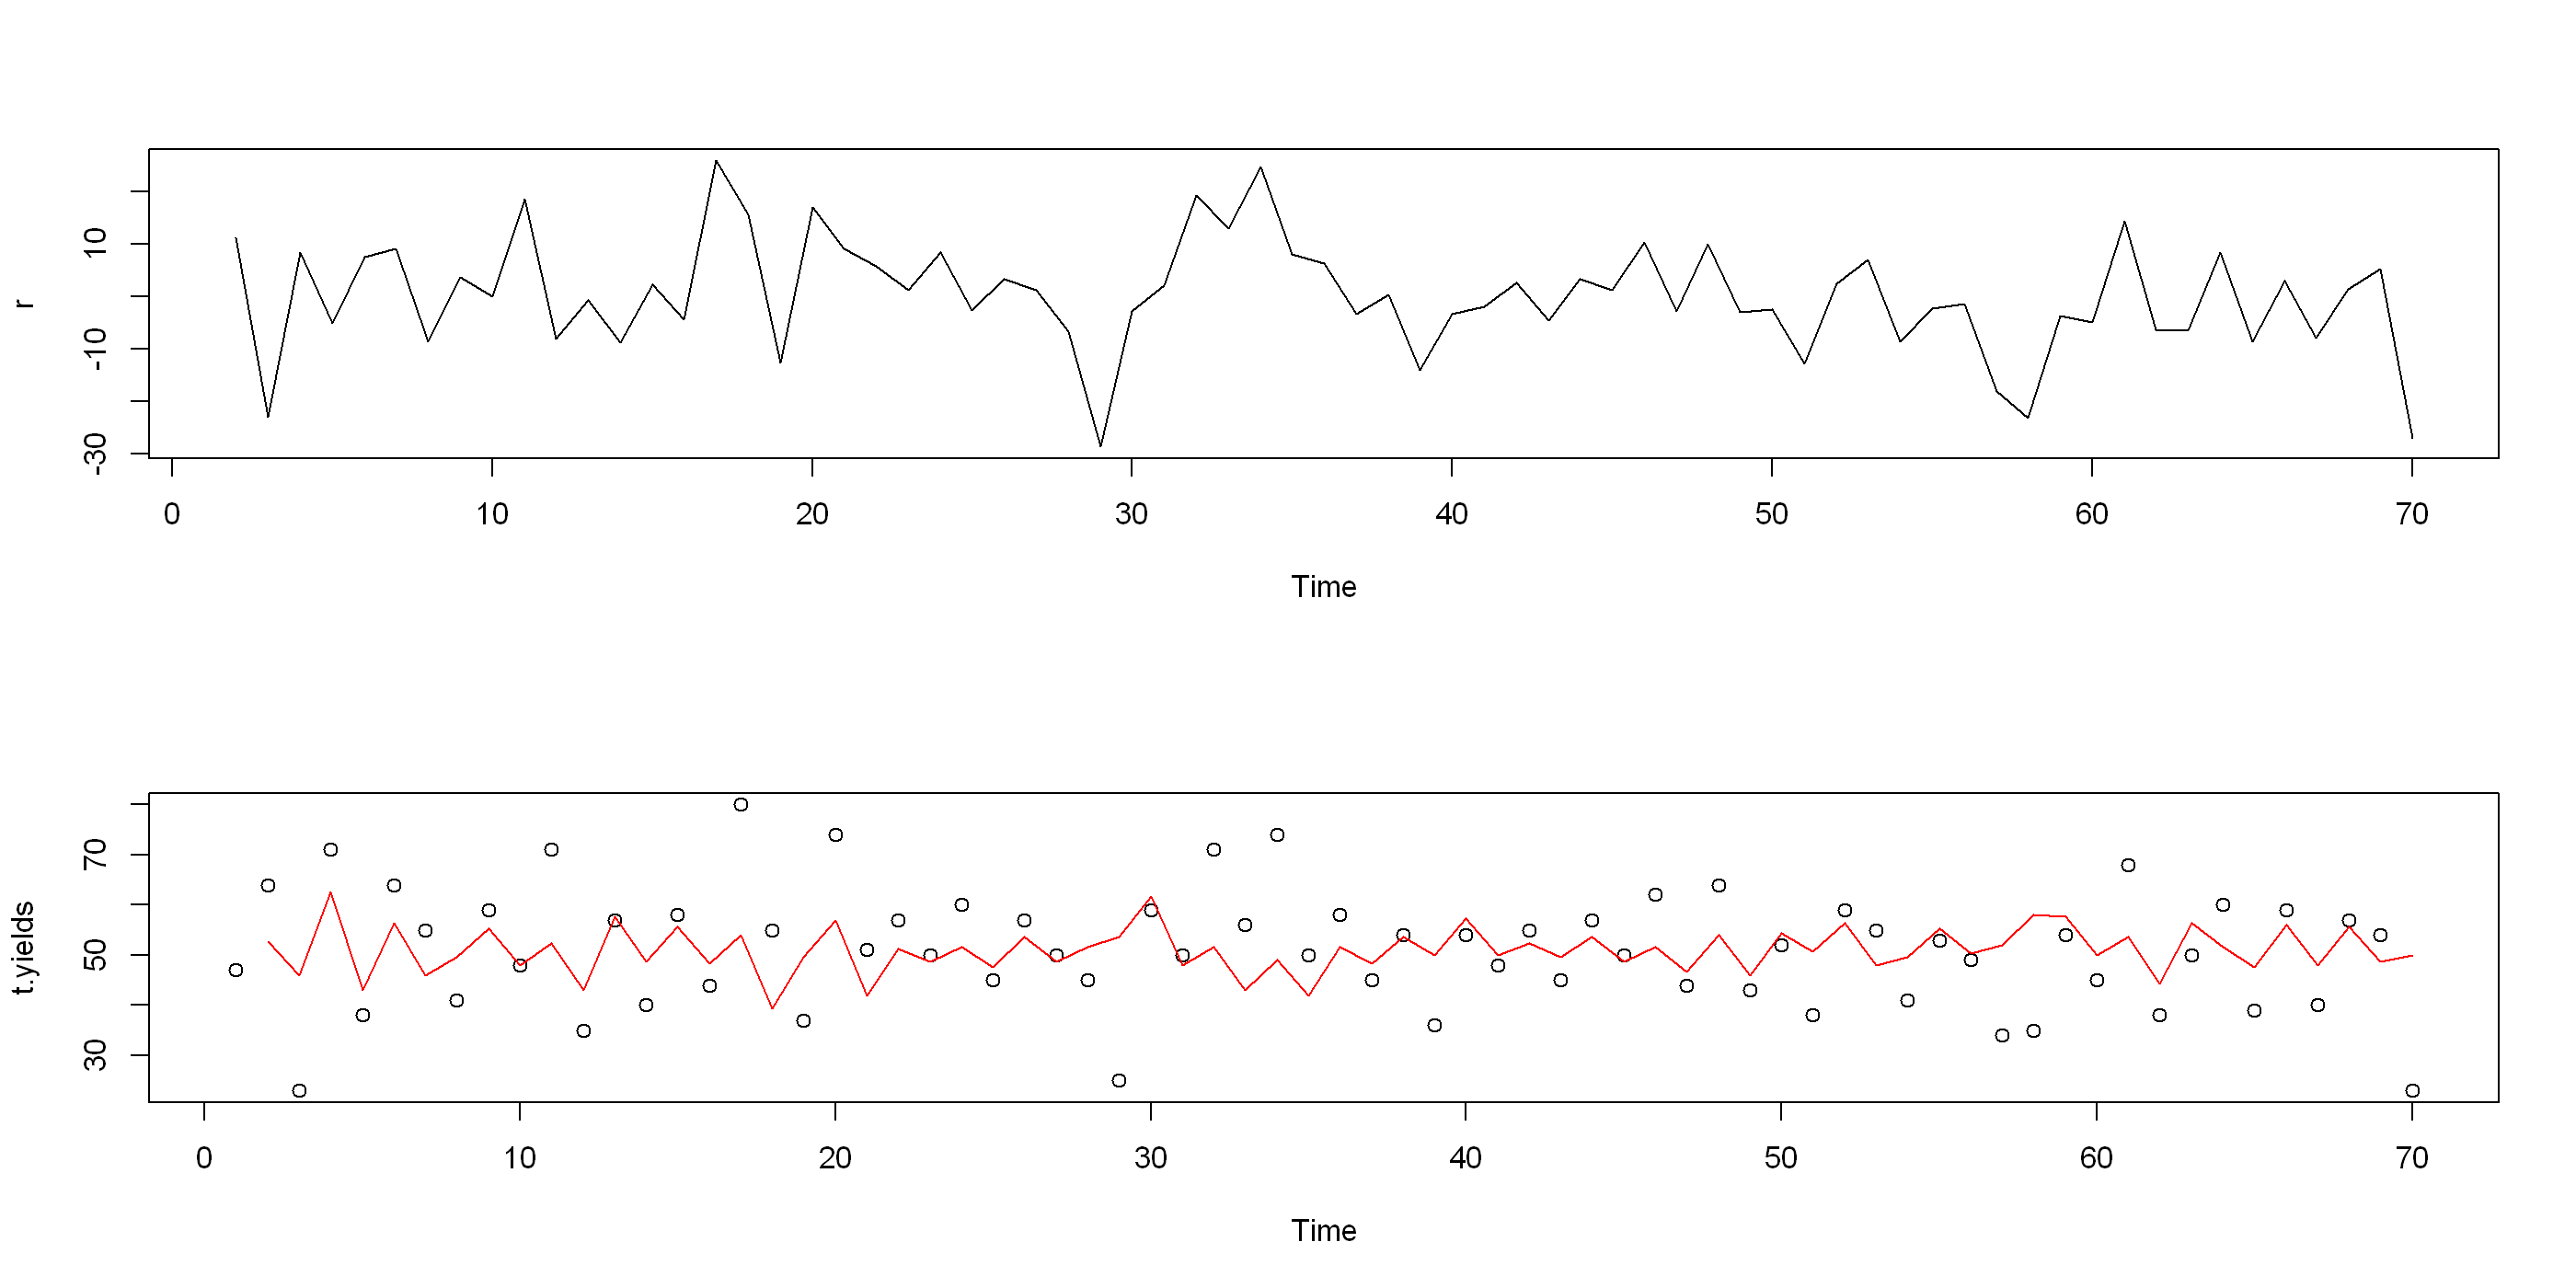

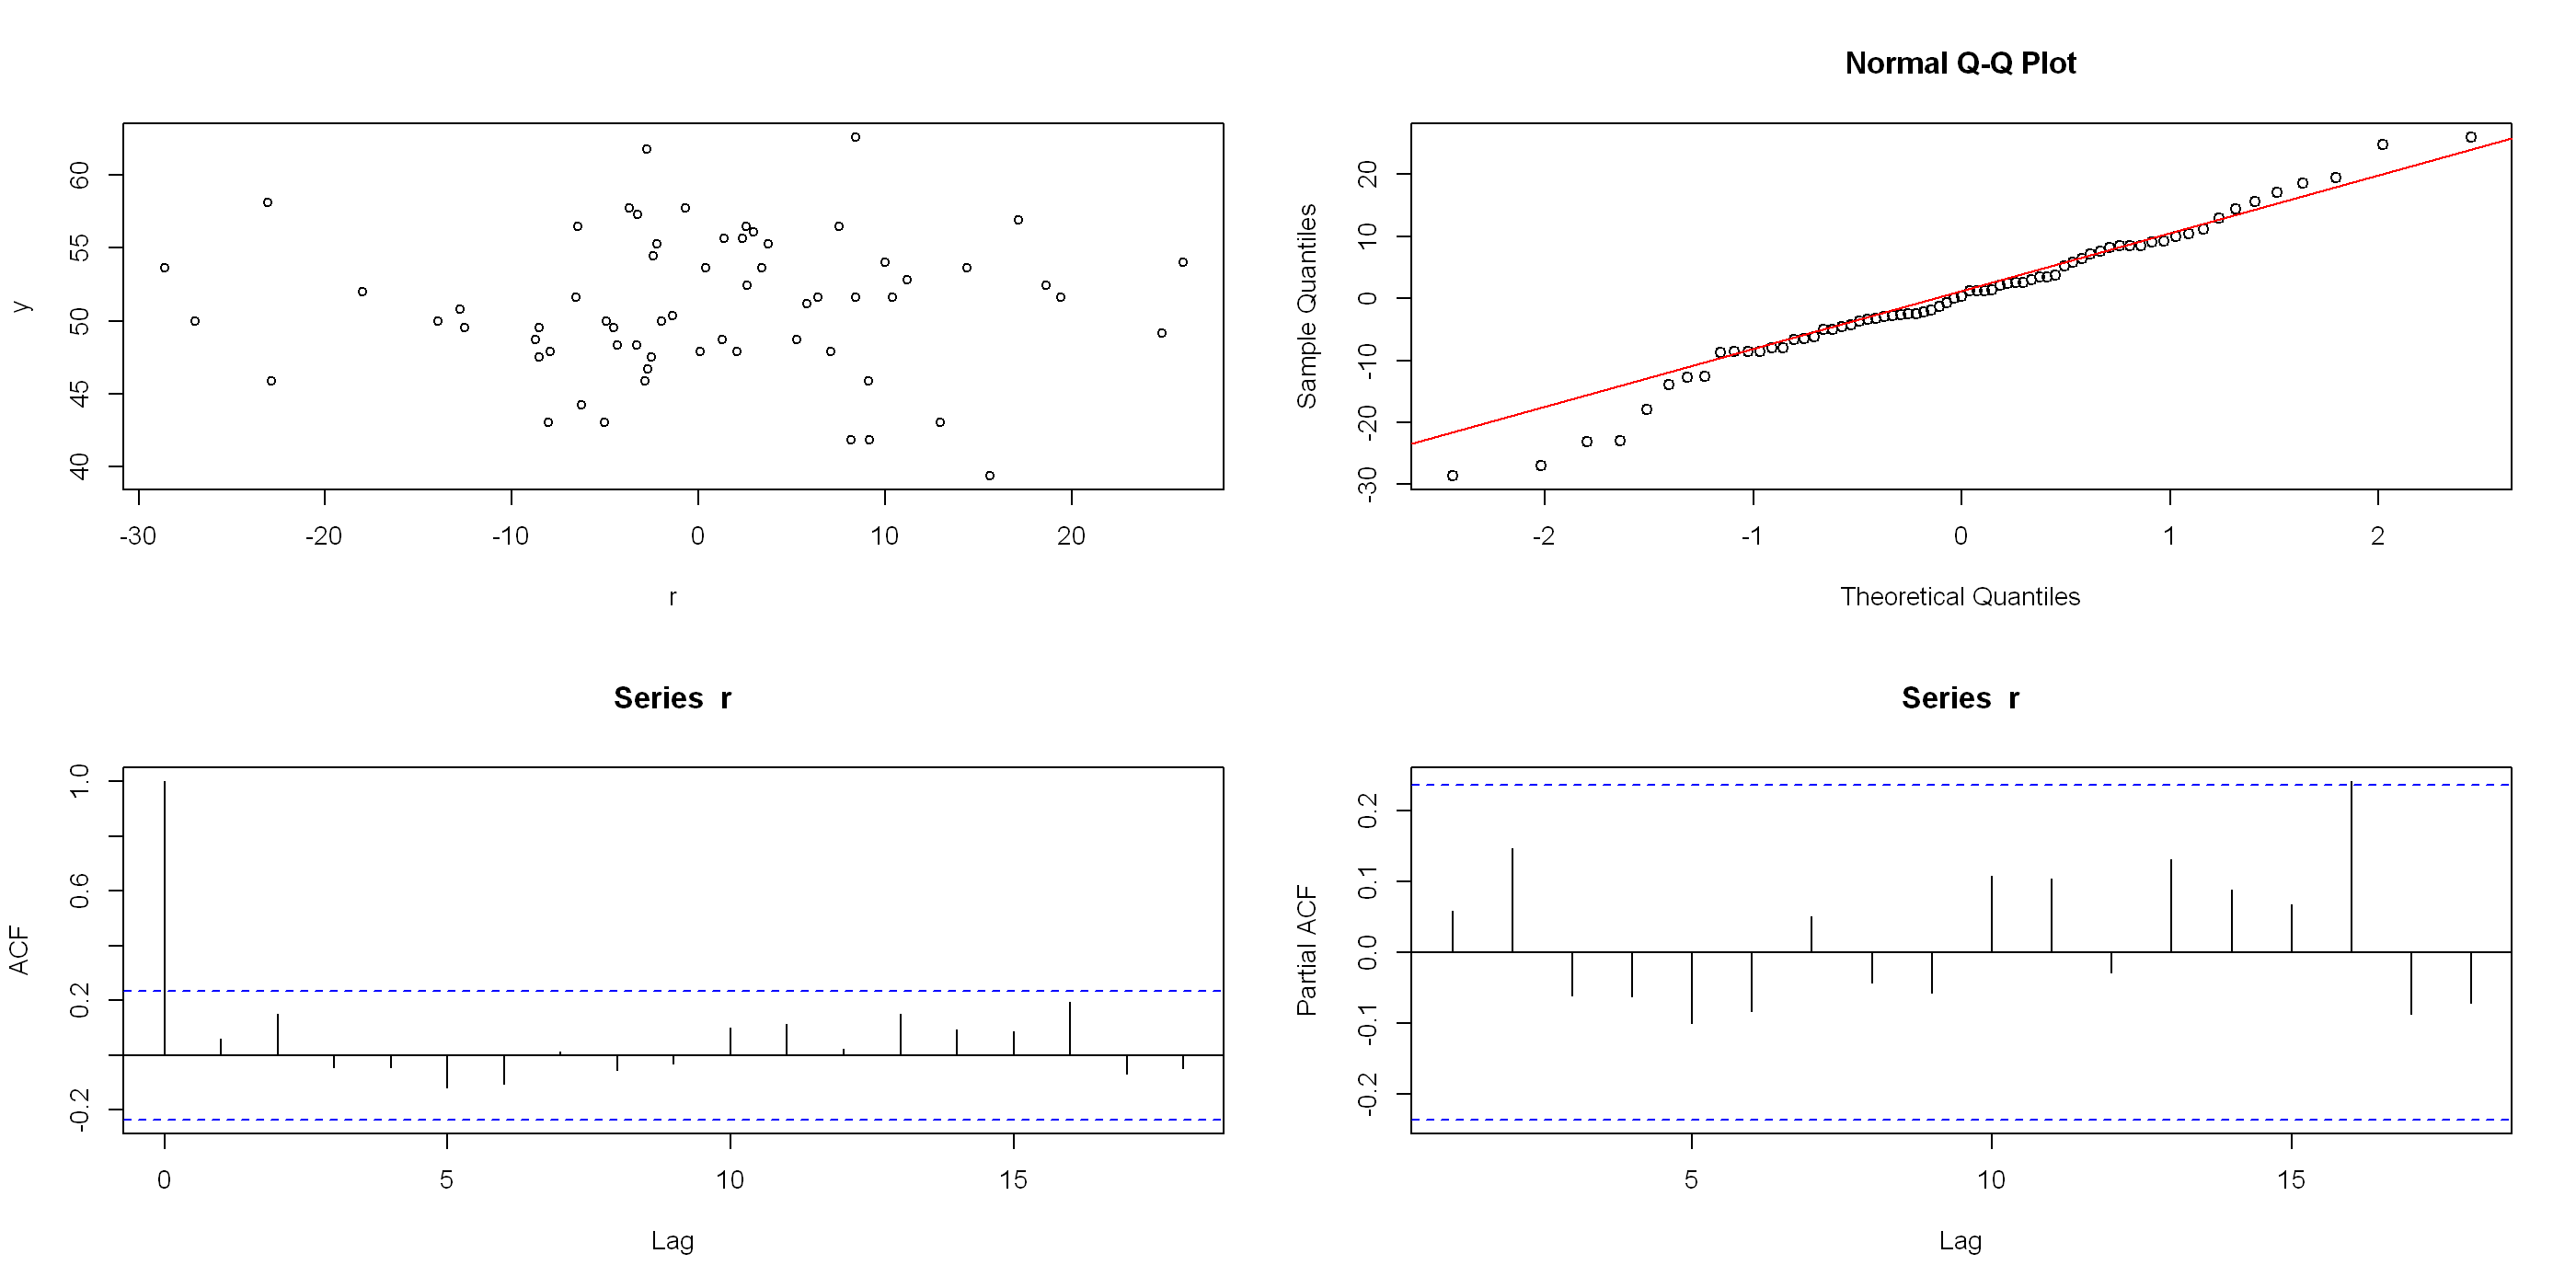

In [243]:
r <- na.omit(r.burg$resid)
y <- t.yields-r
par(mfrow = c(2,1))
plot(r)
plot(t.yields,type="p")
lines(y,col="red")
par(mfrow = c(2,2))

plot(r,y,type="p",xy.labels = FALSE, xy.lines = FALSE)
qqnorm(r)
qqline(r,col="red")
acf(r)
pacf(r)


In [244]:
r.mle <- arima(t.yields,order=c(1,0,0),include.mean = T)
print(r.mle)


Call:
arima(x = t.yields, order = c(1, 0, 0), include.mean = T)

Coefficients:
          ar1  intercept
      -0.4191    51.2658
s.e.   0.1129     0.9137

sigma^2 estimated as 116.6:  log likelihood = -265.98,  aic = 537.96


In [245]:
CI <- c(r.mle$coef[["intercept"]]-qnorm(0.975)*sqrt(diag(r.mle$var.coef))[["intercept"]],r.mle$coef[["intercept"]]+qnorm(0.975)*sqrt(diag(r.mle$var.coef))[["intercept"]])

print(CI)

[1] 49.47495 53.05669


In [246]:
mean(t.yields)

[1] 51.12857

In [247]:
var_2 <- 0
for (i in seq_len(70-1)) {
  var_2 <- var_2 + (2*(70-i)*alpha1^i)
}



var_2 <- var_2 + 70
var_2 <- var_2*var(t.yields)/70^2
var_2

[1] 0.8664761

In [248]:
options(repr.plot.width = 10, repr.plot.height = 7, repr.plot.res = 200)

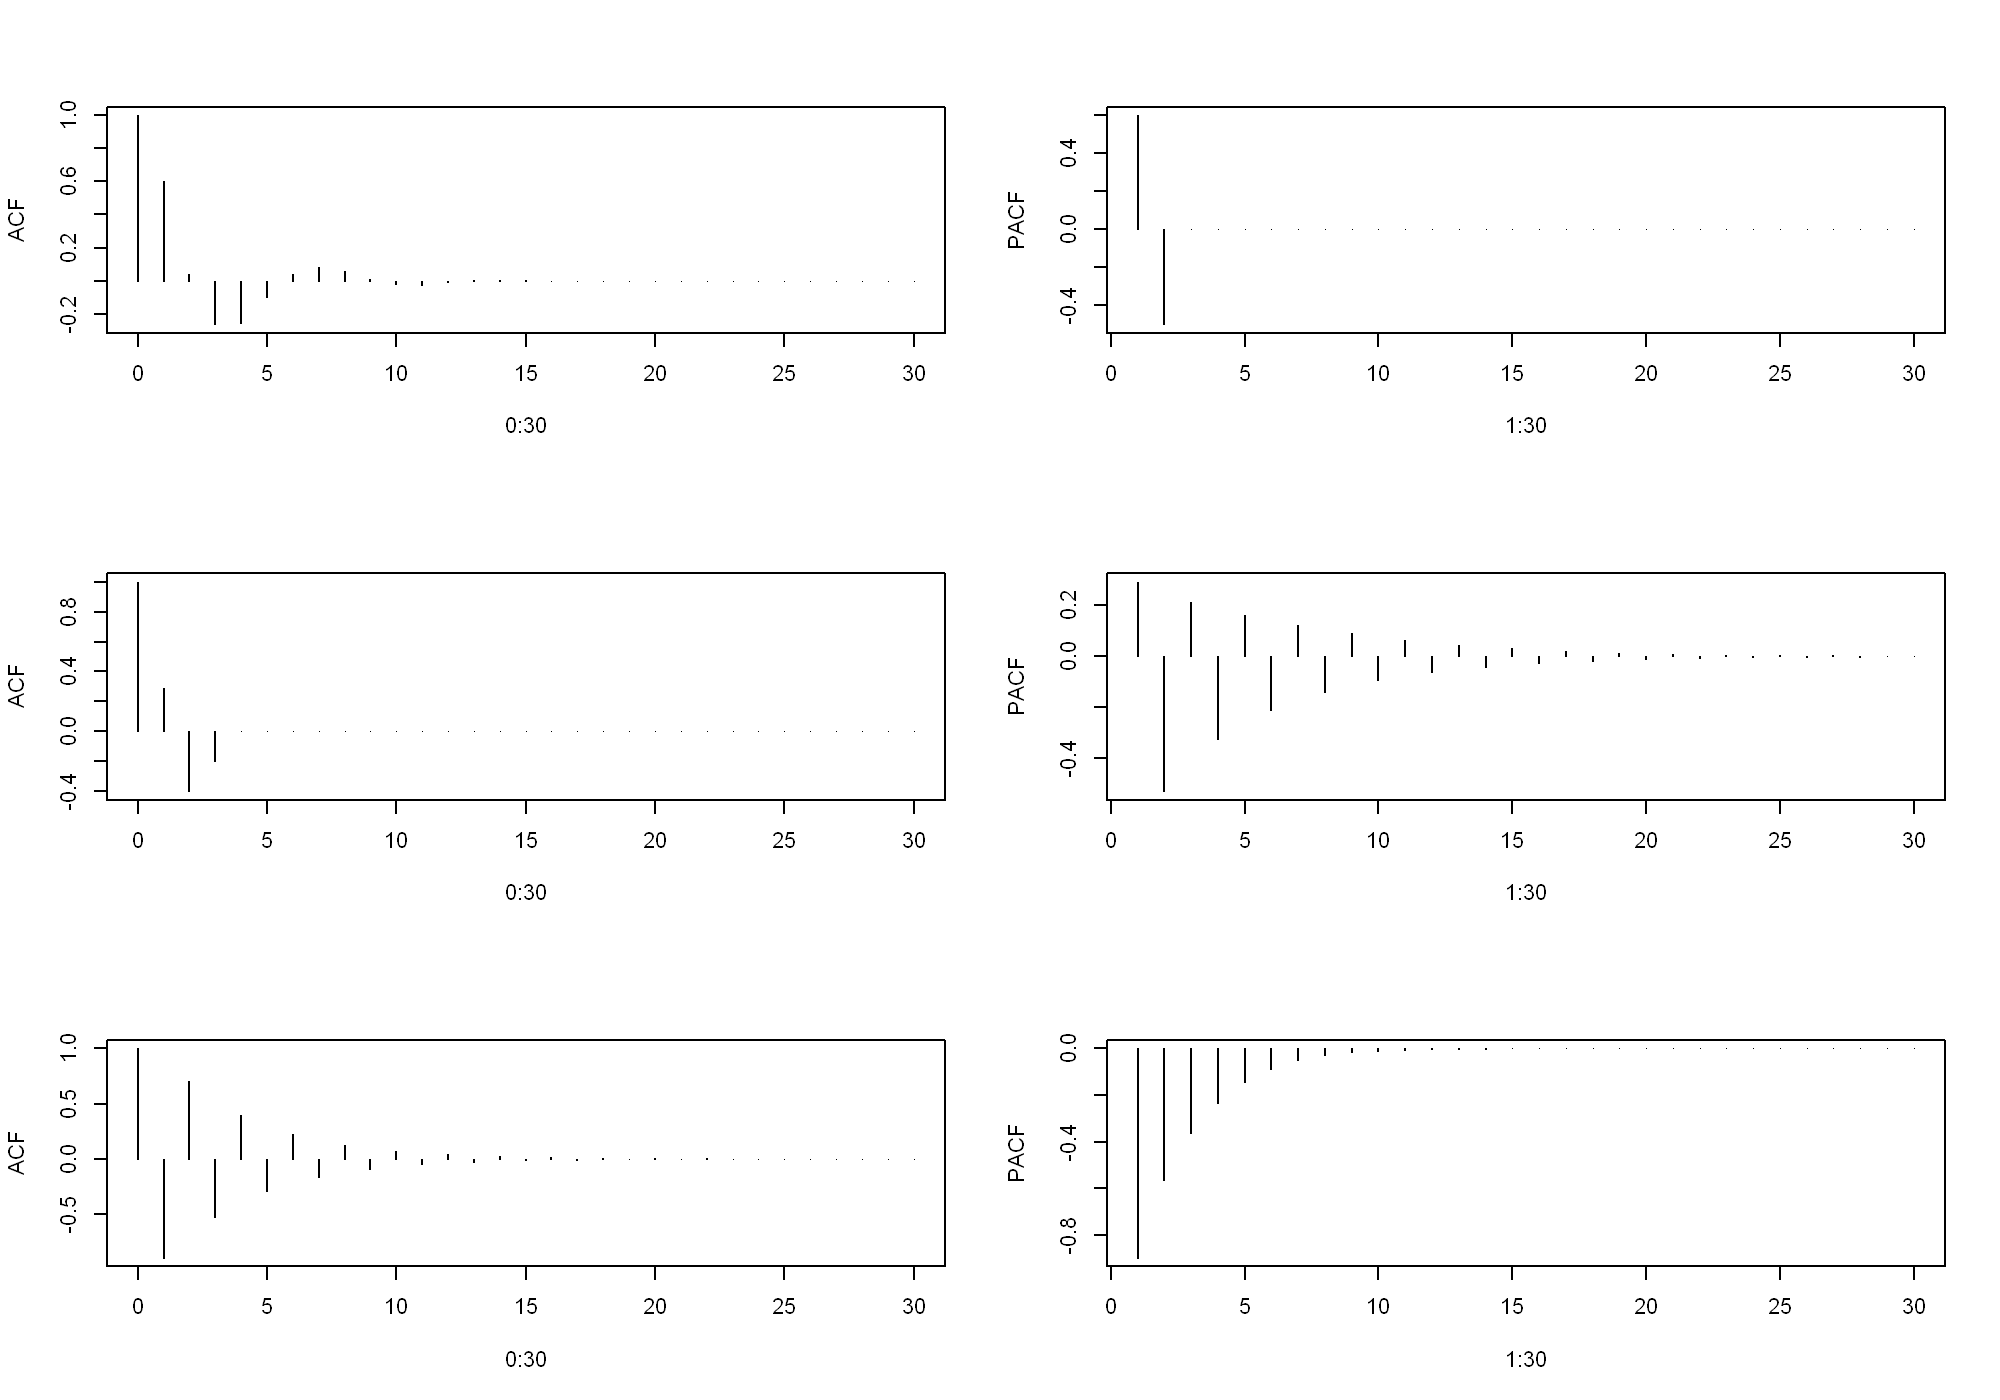

In [249]:
## Theoretical autocorrelations for a)
par(mfrow = c(3,2))
plot(0:30, ARMAacf(ar=c(0.9,-0.5), lag.max=30), type="h",
ylab="ACF")
## Theoretical partial autocorrelations for a)
plot(1:30, ARMAacf(ar=c(0.9,-0.5), lag.max=30, pacf=T), type="h",
ylab="PACF")

plot(0:30, ARMAacf(ma=c(0.8,-0.5,-0.4), lag.max=30), type="h",
ylab="ACF")
## Theoretical partial autocorrelations for a)
plot(1:30, ARMAacf(ma=c(0.8,-0.5,-0.4), lag.max=30, pacf=T), type="h",
ylab="PACF")


plot(0:30, ARMAacf(ar=c(-0.75),ma=c(-1,0.25), lag.max=30), type="h",
ylab="ACF")
## Theoretical partial autocorrelations for a)
plot(1:30, ARMAacf(ar=c(-0.75),ma=c(-1,0.25), lag.max=30, pacf=T), type="h",
ylab="PACF")


In [250]:
x1 <- arima.sim(n = 200,list(ar=c(0.9,-0.5)))
x2 <- arima.sim(n = 200,list(ma=c(0.8,-0.5,-0.4)))
x3 <- arima.sim(n = 200,list(ar=c(-0.75),ma=c(-1,0.25)))

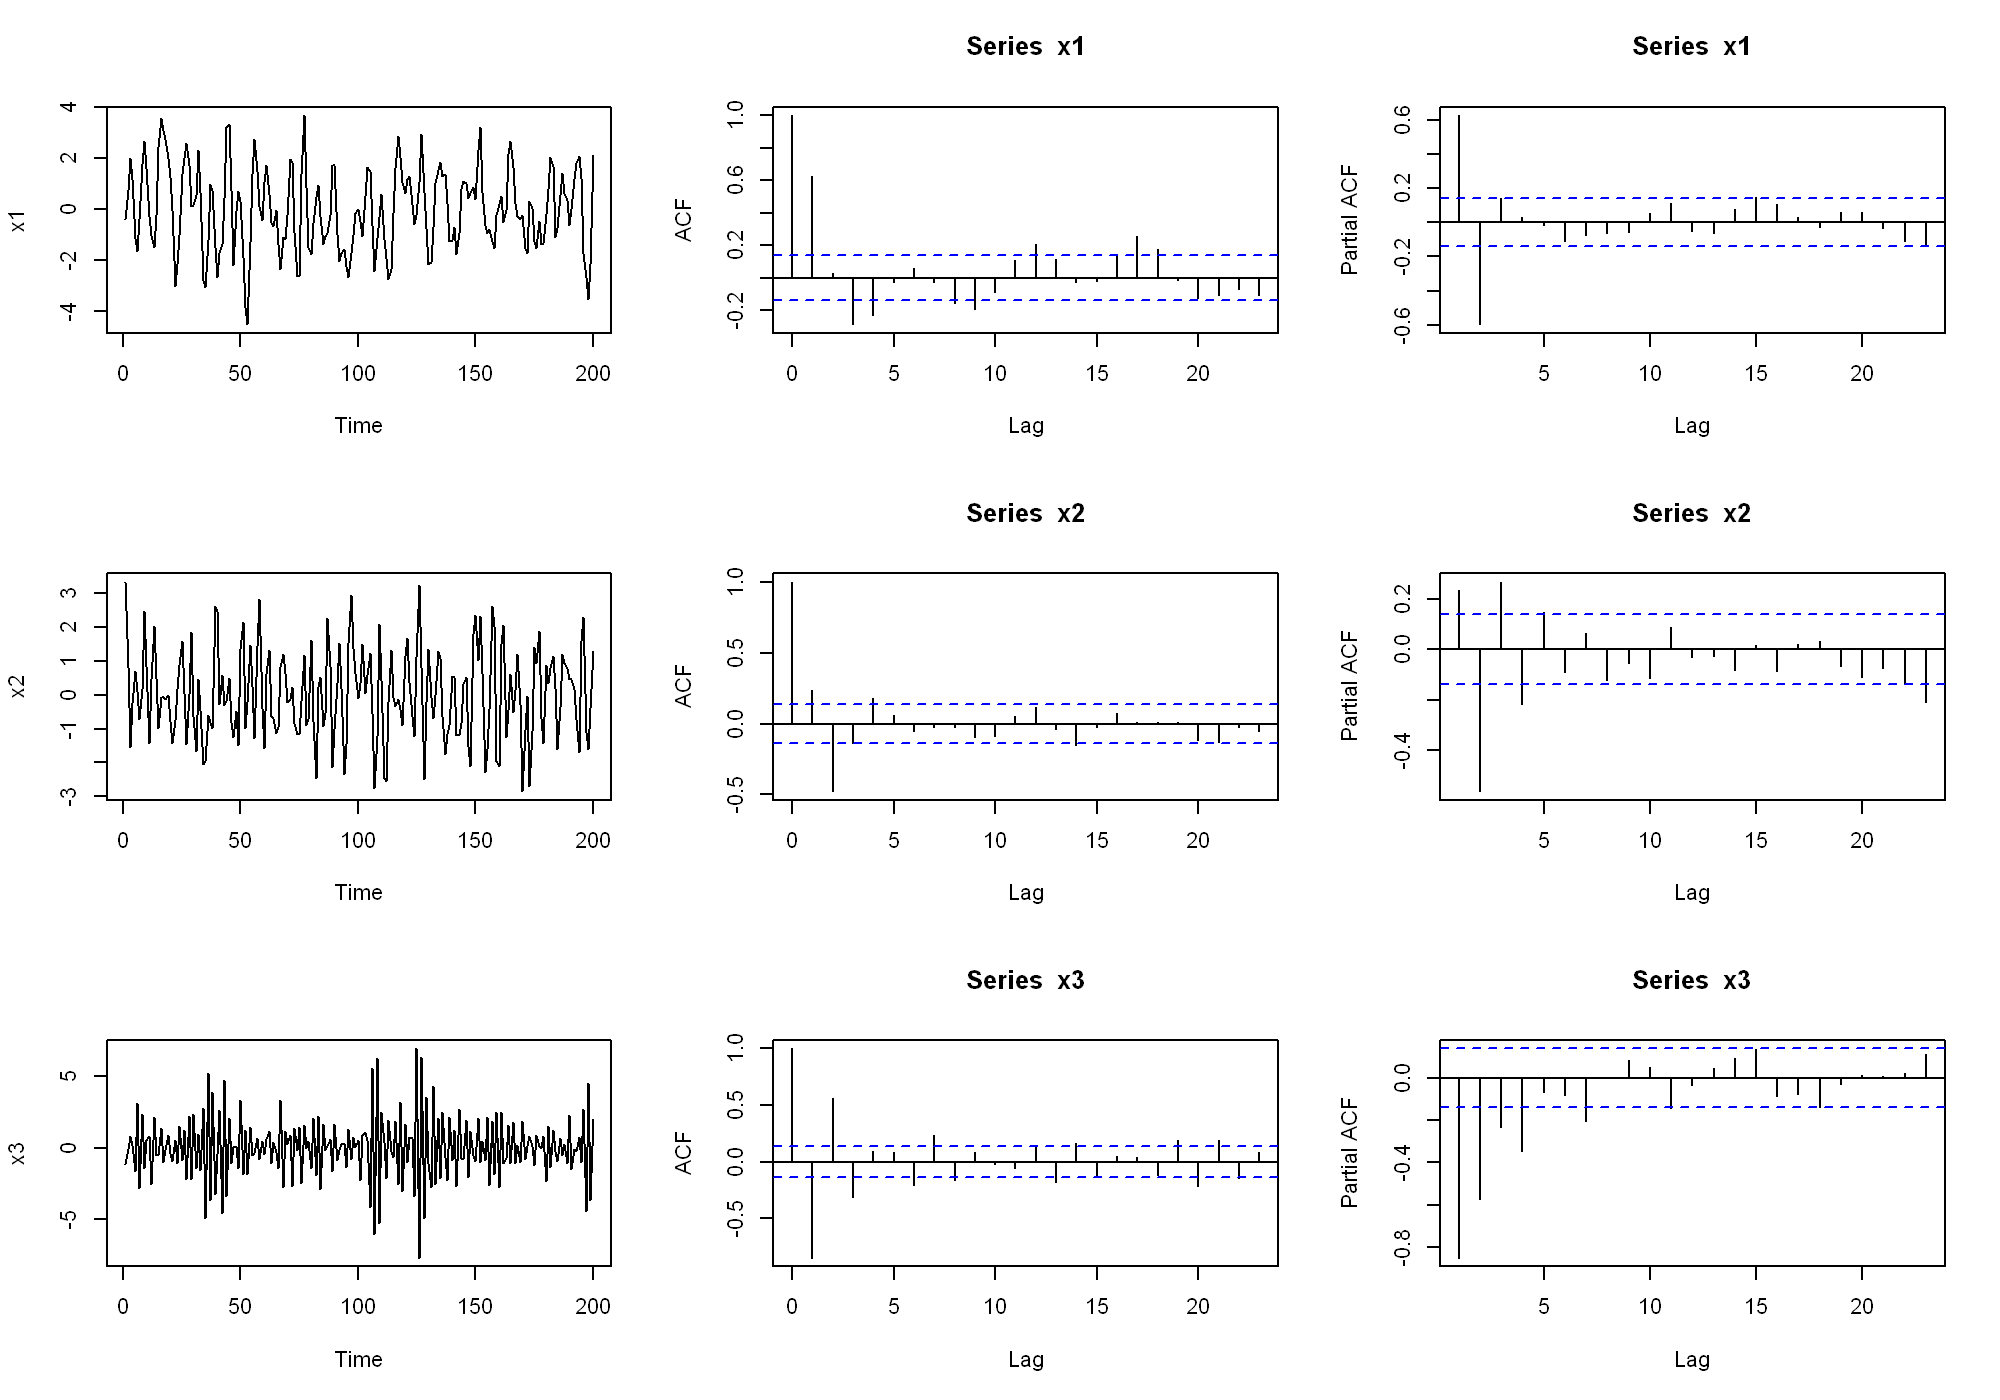

In [251]:
par(mfrow = c(3,3))
plot(x1)
acf(x1)
pacf(x1)
plot(x2)
acf(x2)
pacf(x2)
plot(x3)
acf(x3)
pacf(x3)

In [252]:
dat <- read.table("http://stat.ethz.ch/Teaching/Datasets/WBL/mcARMA.dat",
header = TRUE)
ts <- ts(dat$x)

In [253]:
options(repr.plot.width = 14, repr.plot.height = 7, repr.plot.res = 200)

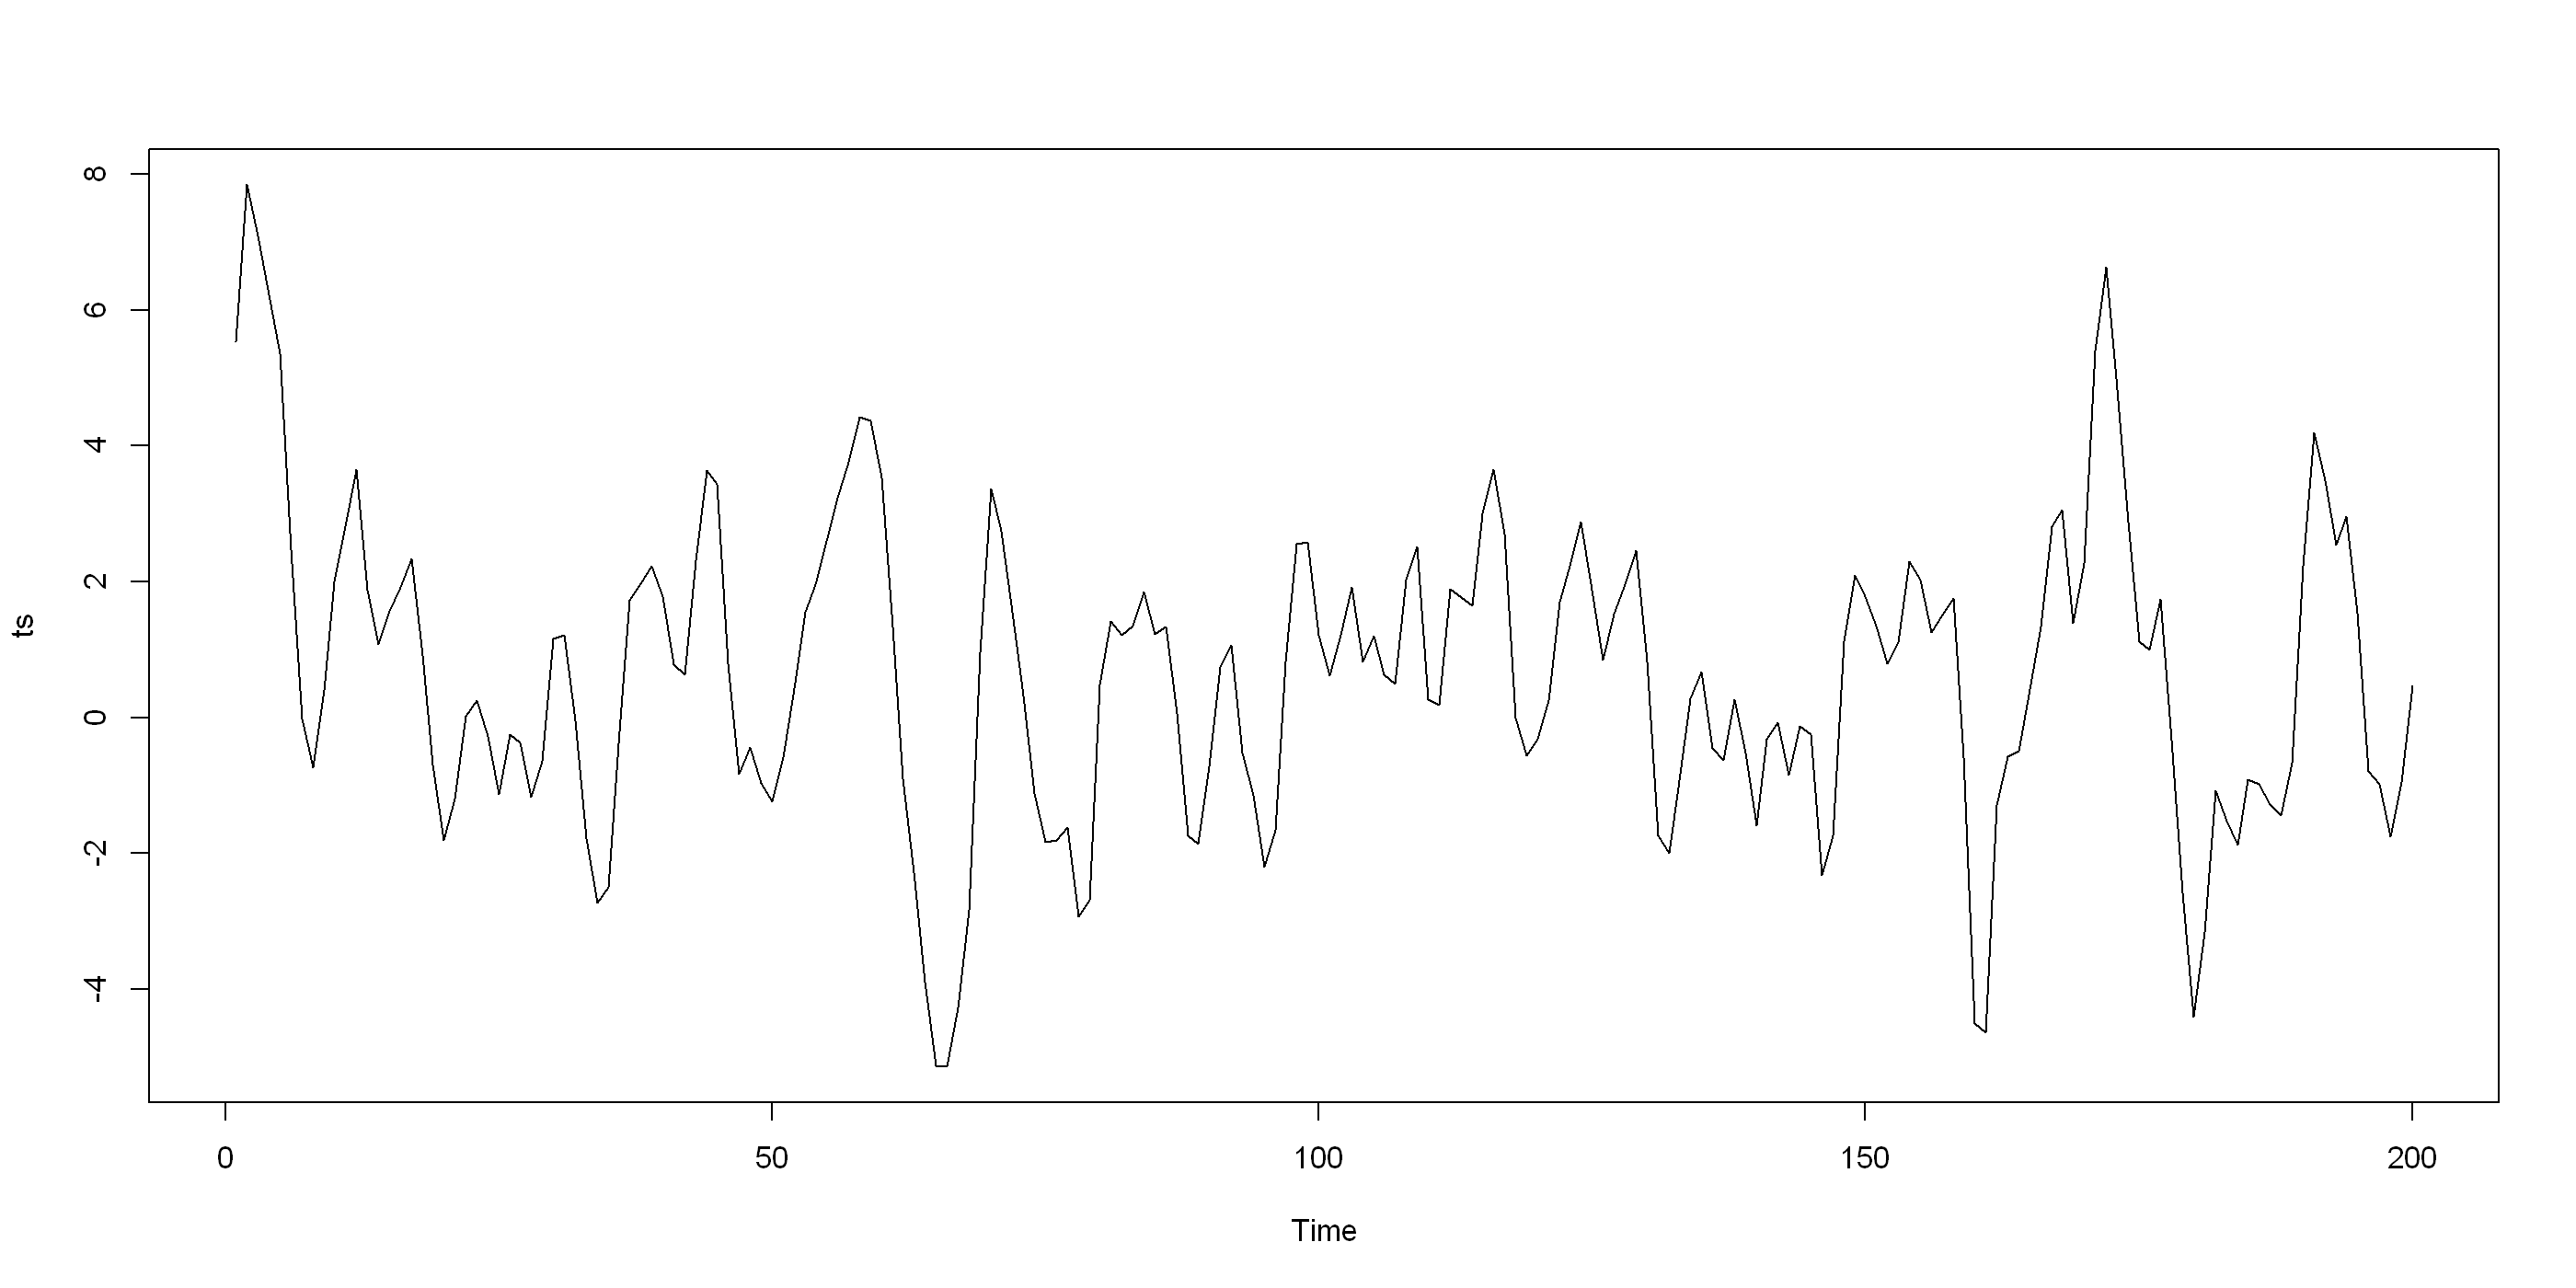

In [254]:
plot(ts)

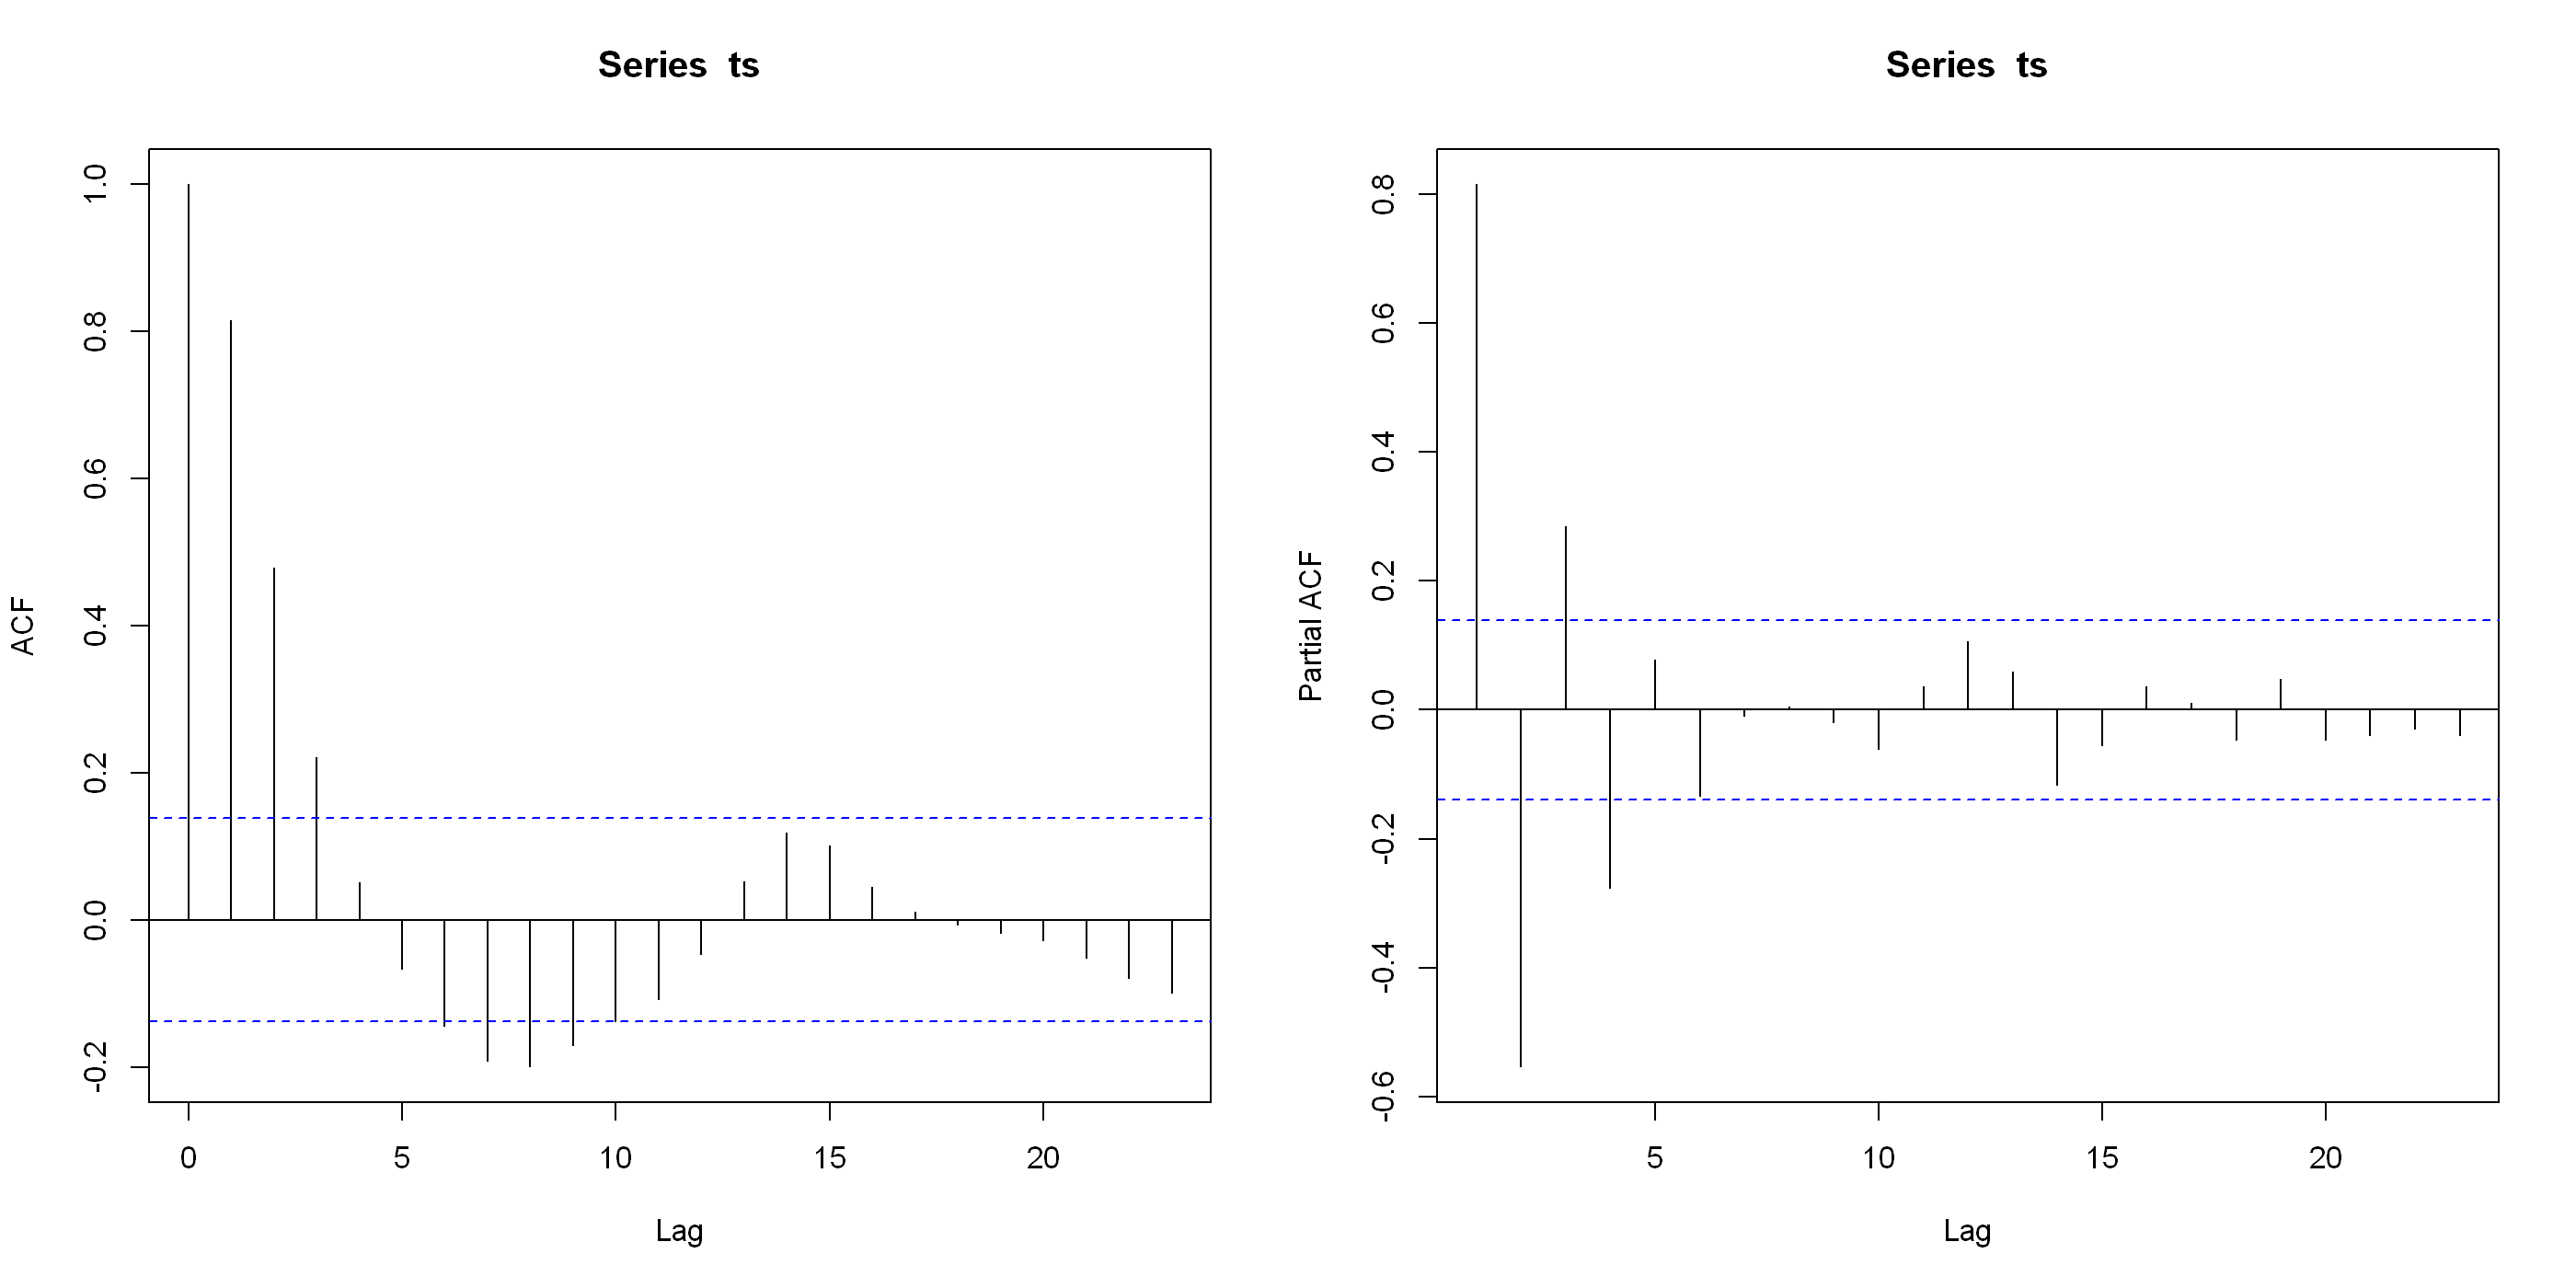

In [255]:
par(mfrow = c(1,2))
acf(ts)
pacf(ts)

In [256]:
f1 <- arima(ts,order = c(3,0,0))
f2 <- arima(ts,order= c(0,0,9))
f3 <- arima(ts,order =c(3,0,3))

Warning message in arima(ts, order = c(3, 0, 3)):
"possible convergence problem: optim gave code = 1"


In [257]:
options(repr.plot.width = 10, repr.plot.height = 7, repr.plot.res = 200)

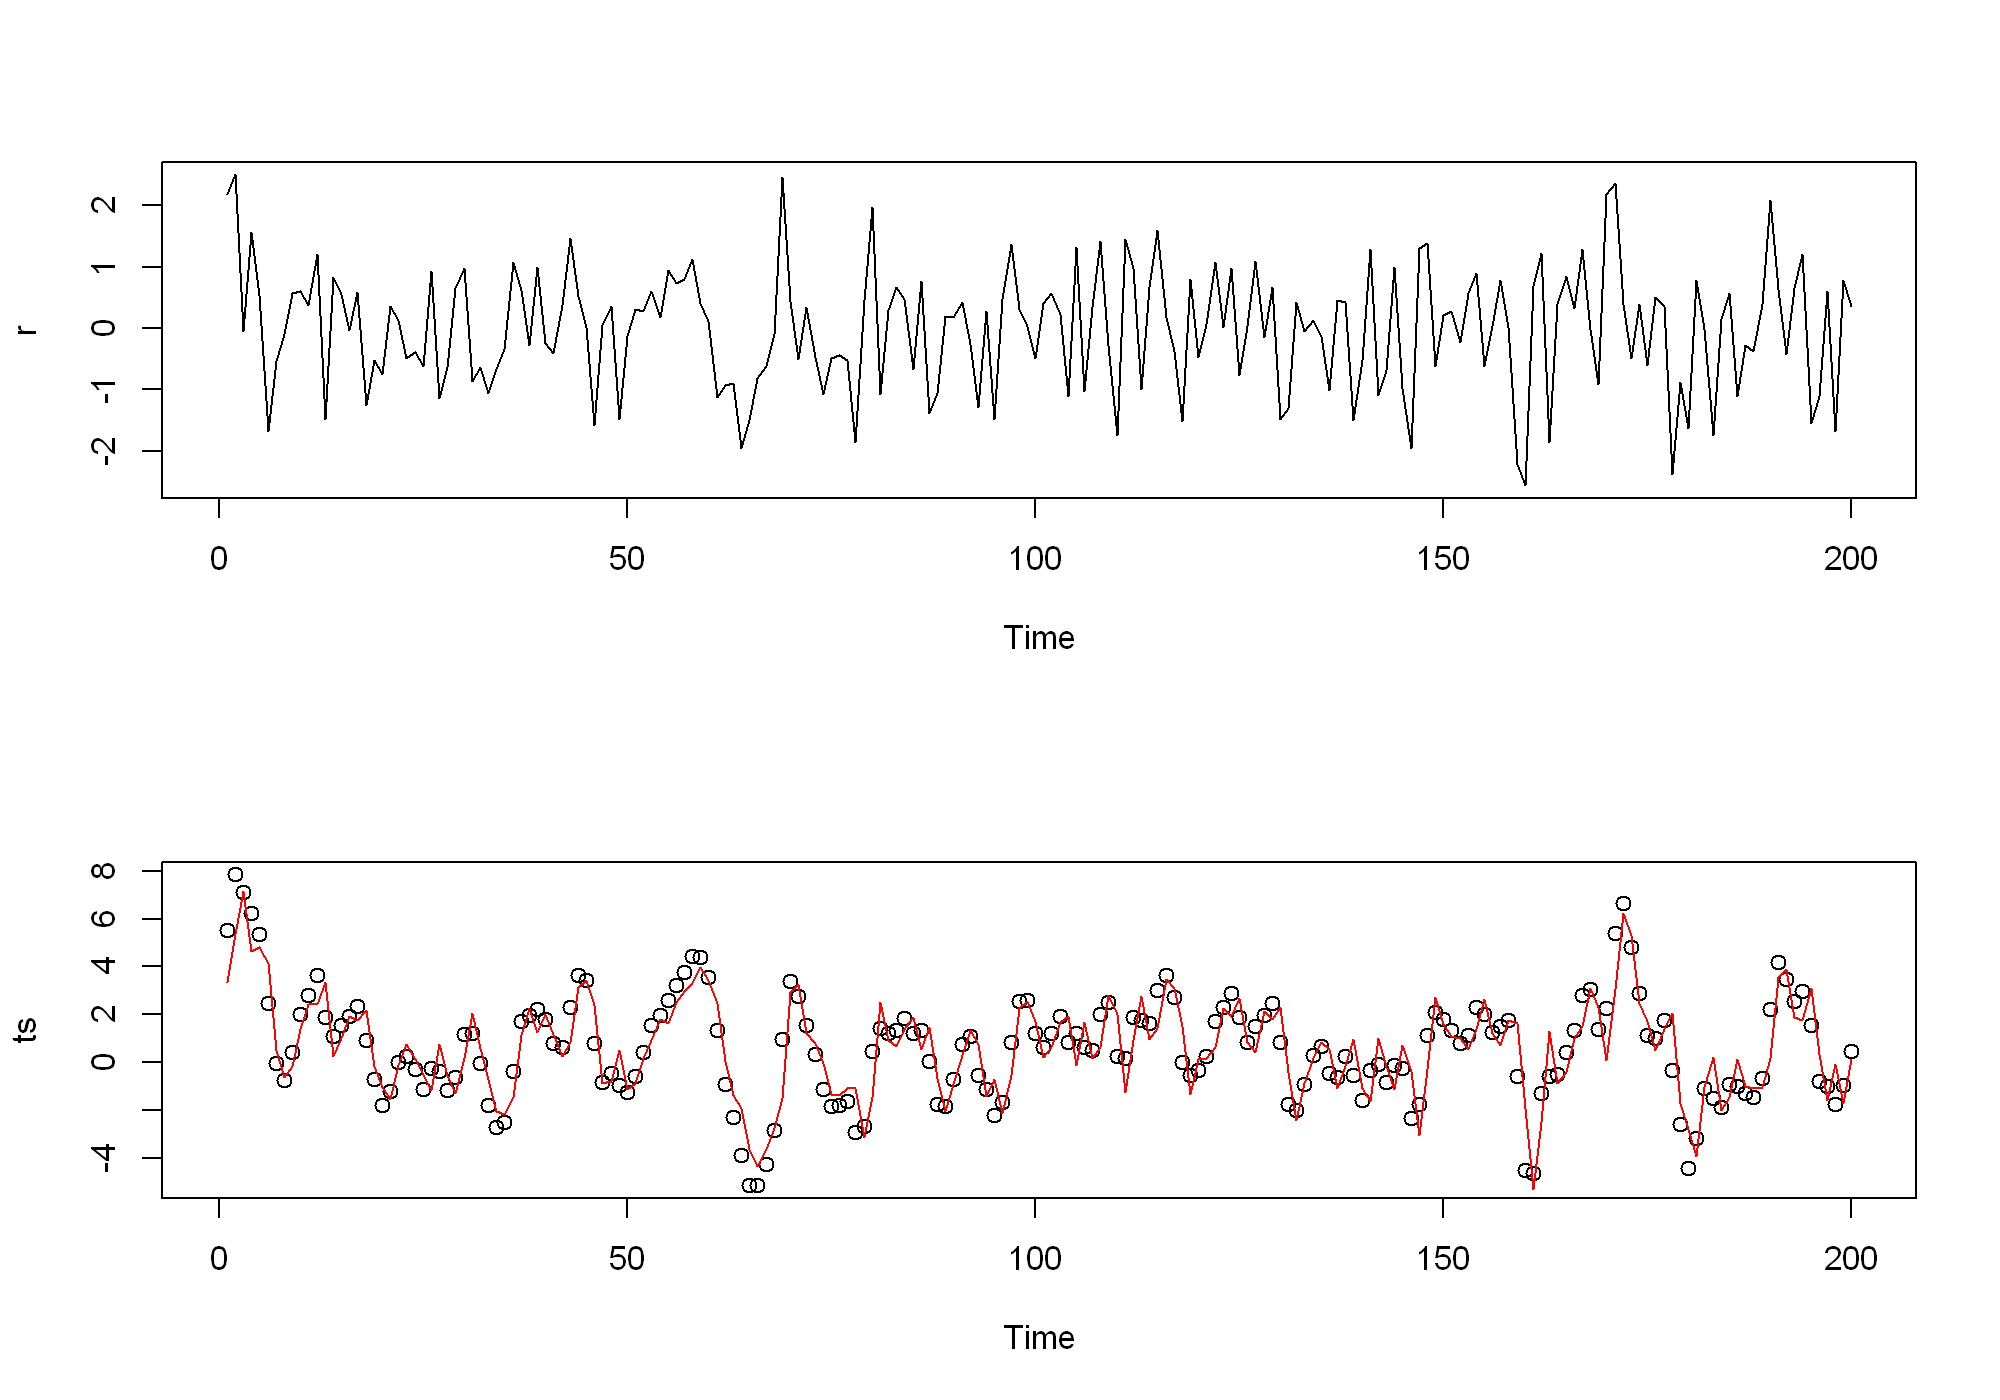


Call:
arima(x = ts, order = c(3, 0, 0))

Coefficients:
         ar1      ar2     ar3  intercept
      1.4541  -0.9503  0.3028     0.6642
s.e.  0.0674   0.1039  0.0692     0.3575

sigma^2 estimated as 0.9764:  log likelihood = -282.49,  aic = 574.98

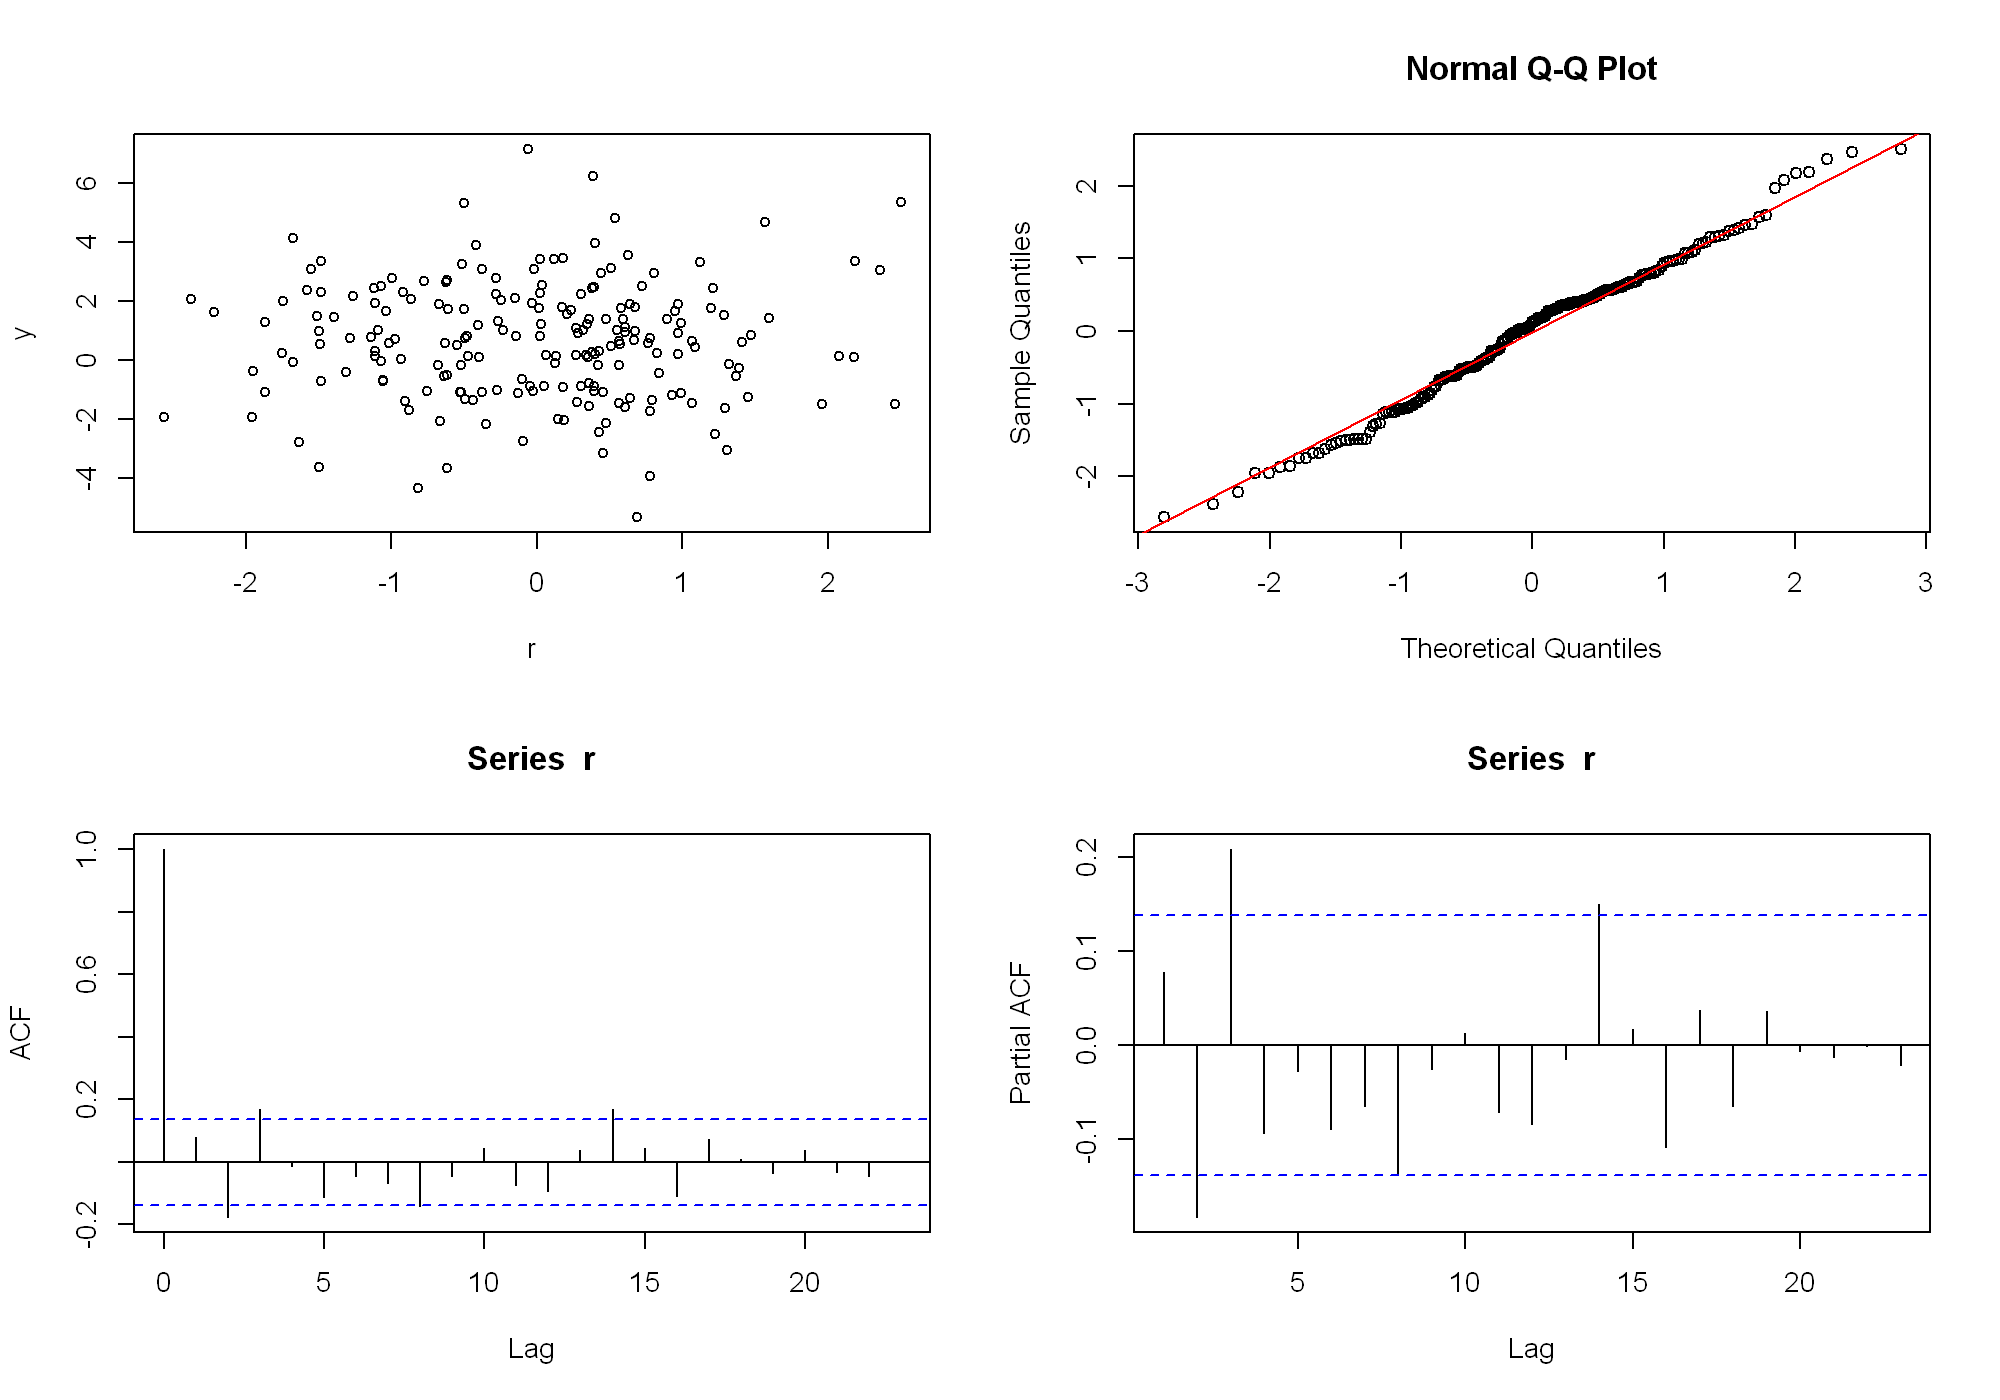

In [ ]:
r <- na.omit(f1$residuals)
y <- ts-r
par(mfrow = c(2,1))
plot(r)
plot(ts,type="p")
lines(y,col="red")
par(mfrow = c(2,2))

plot(r,y,type="p",xy.labels = FALSE, xy.lines = FALSE)
qqnorm(r)
qqline(r,col="red")
acf(r)
pacf(r)

f1


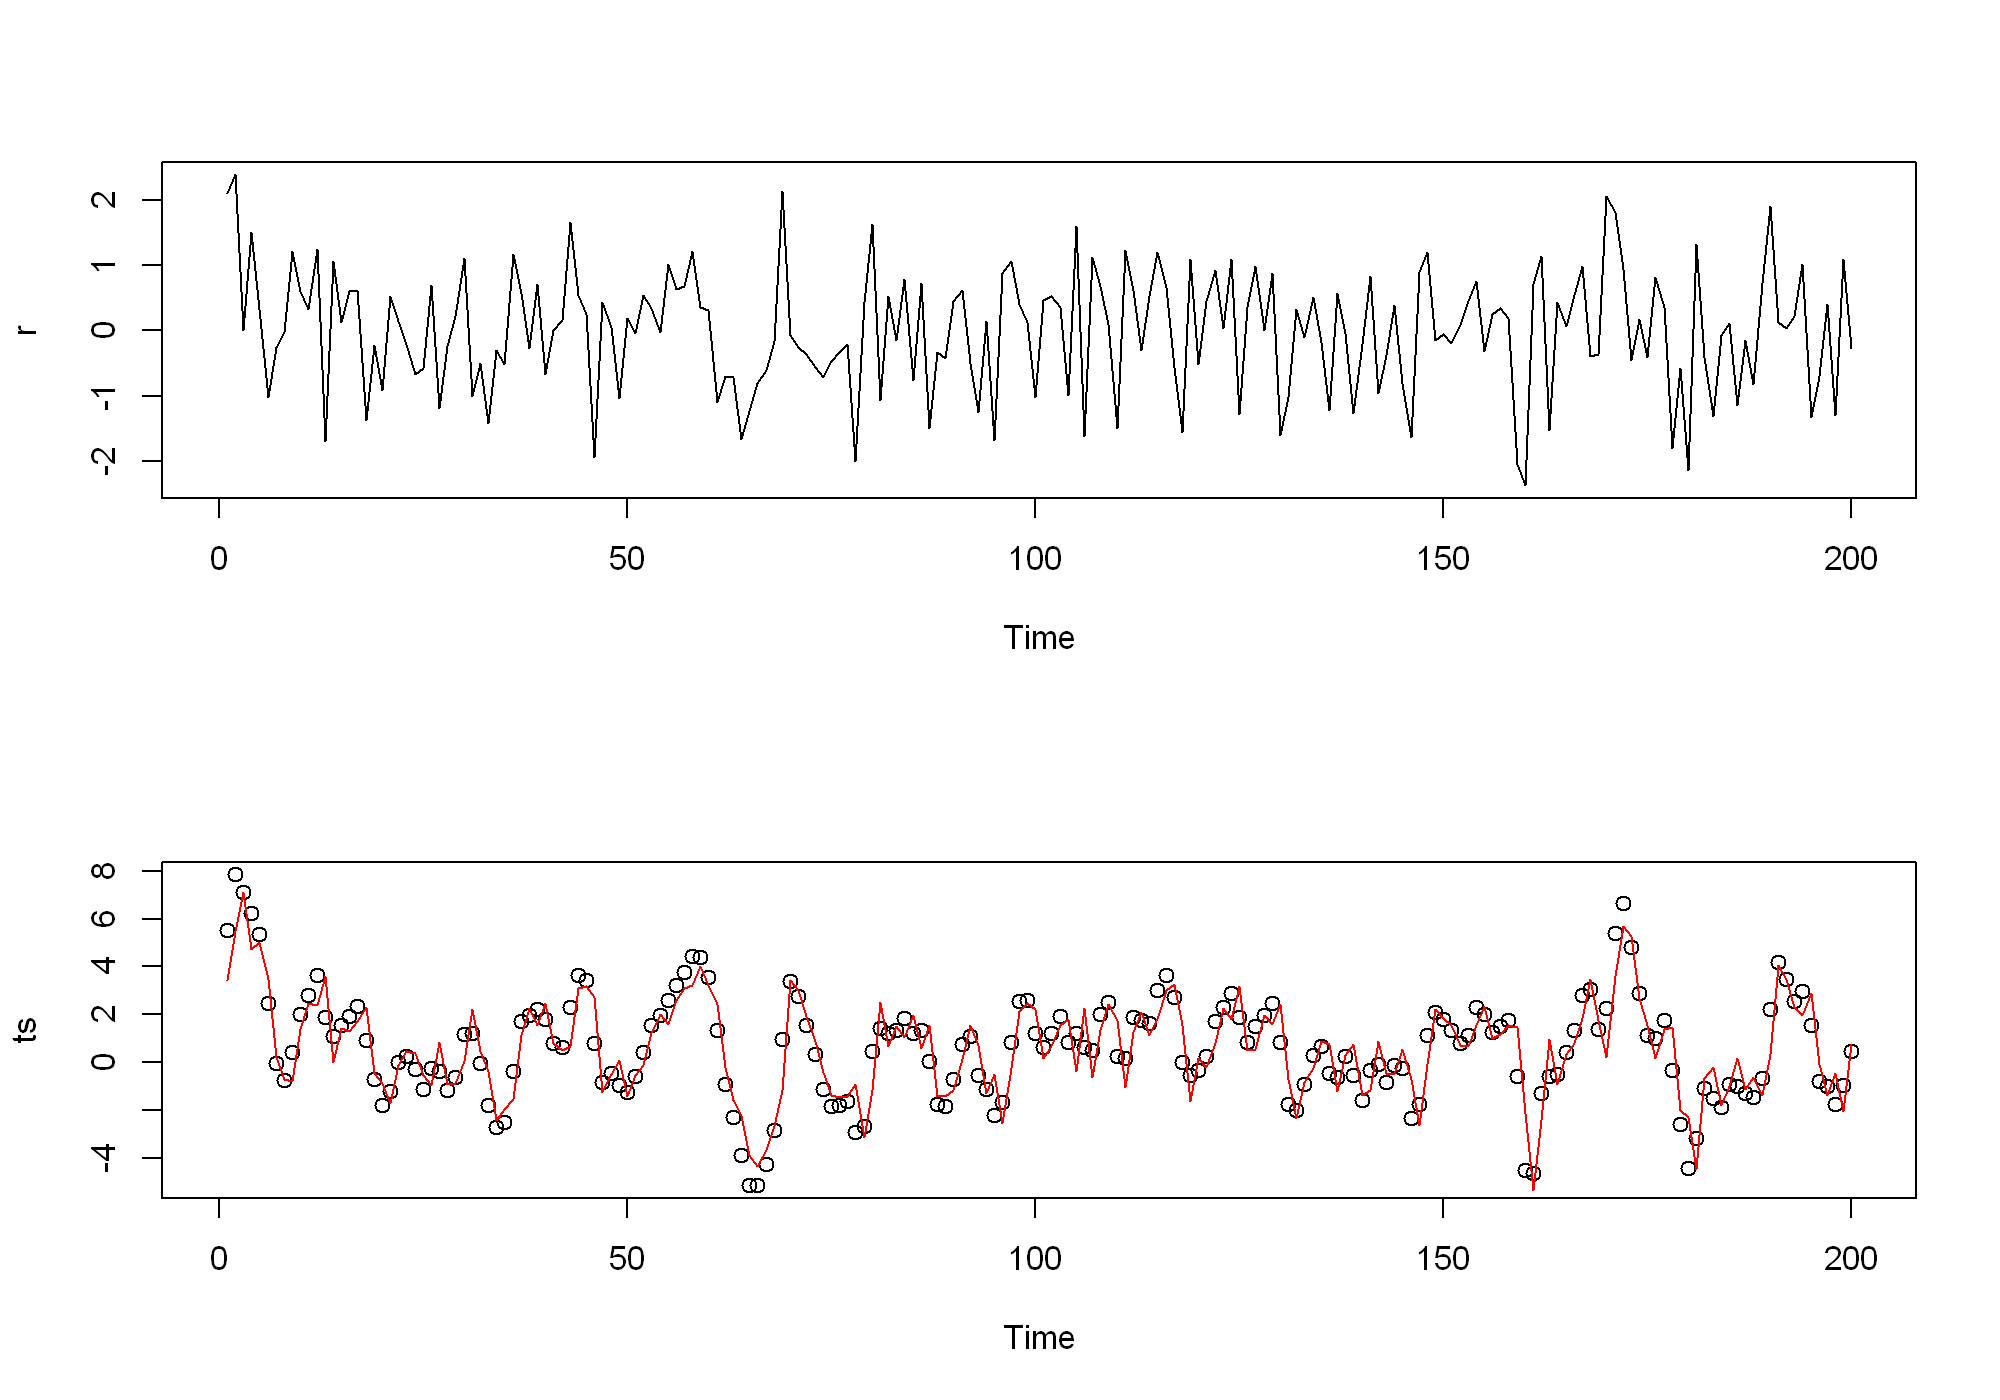


Call:
arima(x = ts, order = c(0, 0, 9))

Coefficients:
         ma1     ma2     ma3     ma4     ma5      ma6      ma7      ma8
      1.5787  1.1596  0.6559  0.3246  0.0650  -0.0379  -0.0603  -0.1521
s.e.  0.0723  0.1338  0.1638  0.1783  0.2028   0.2239   0.2243   0.1662
          ma9  intercept
      -0.1367     0.6285
s.e.   0.0929     0.2882

sigma^2 estimated as 0.8639:  log likelihood = -270.57,  aic = 563.14

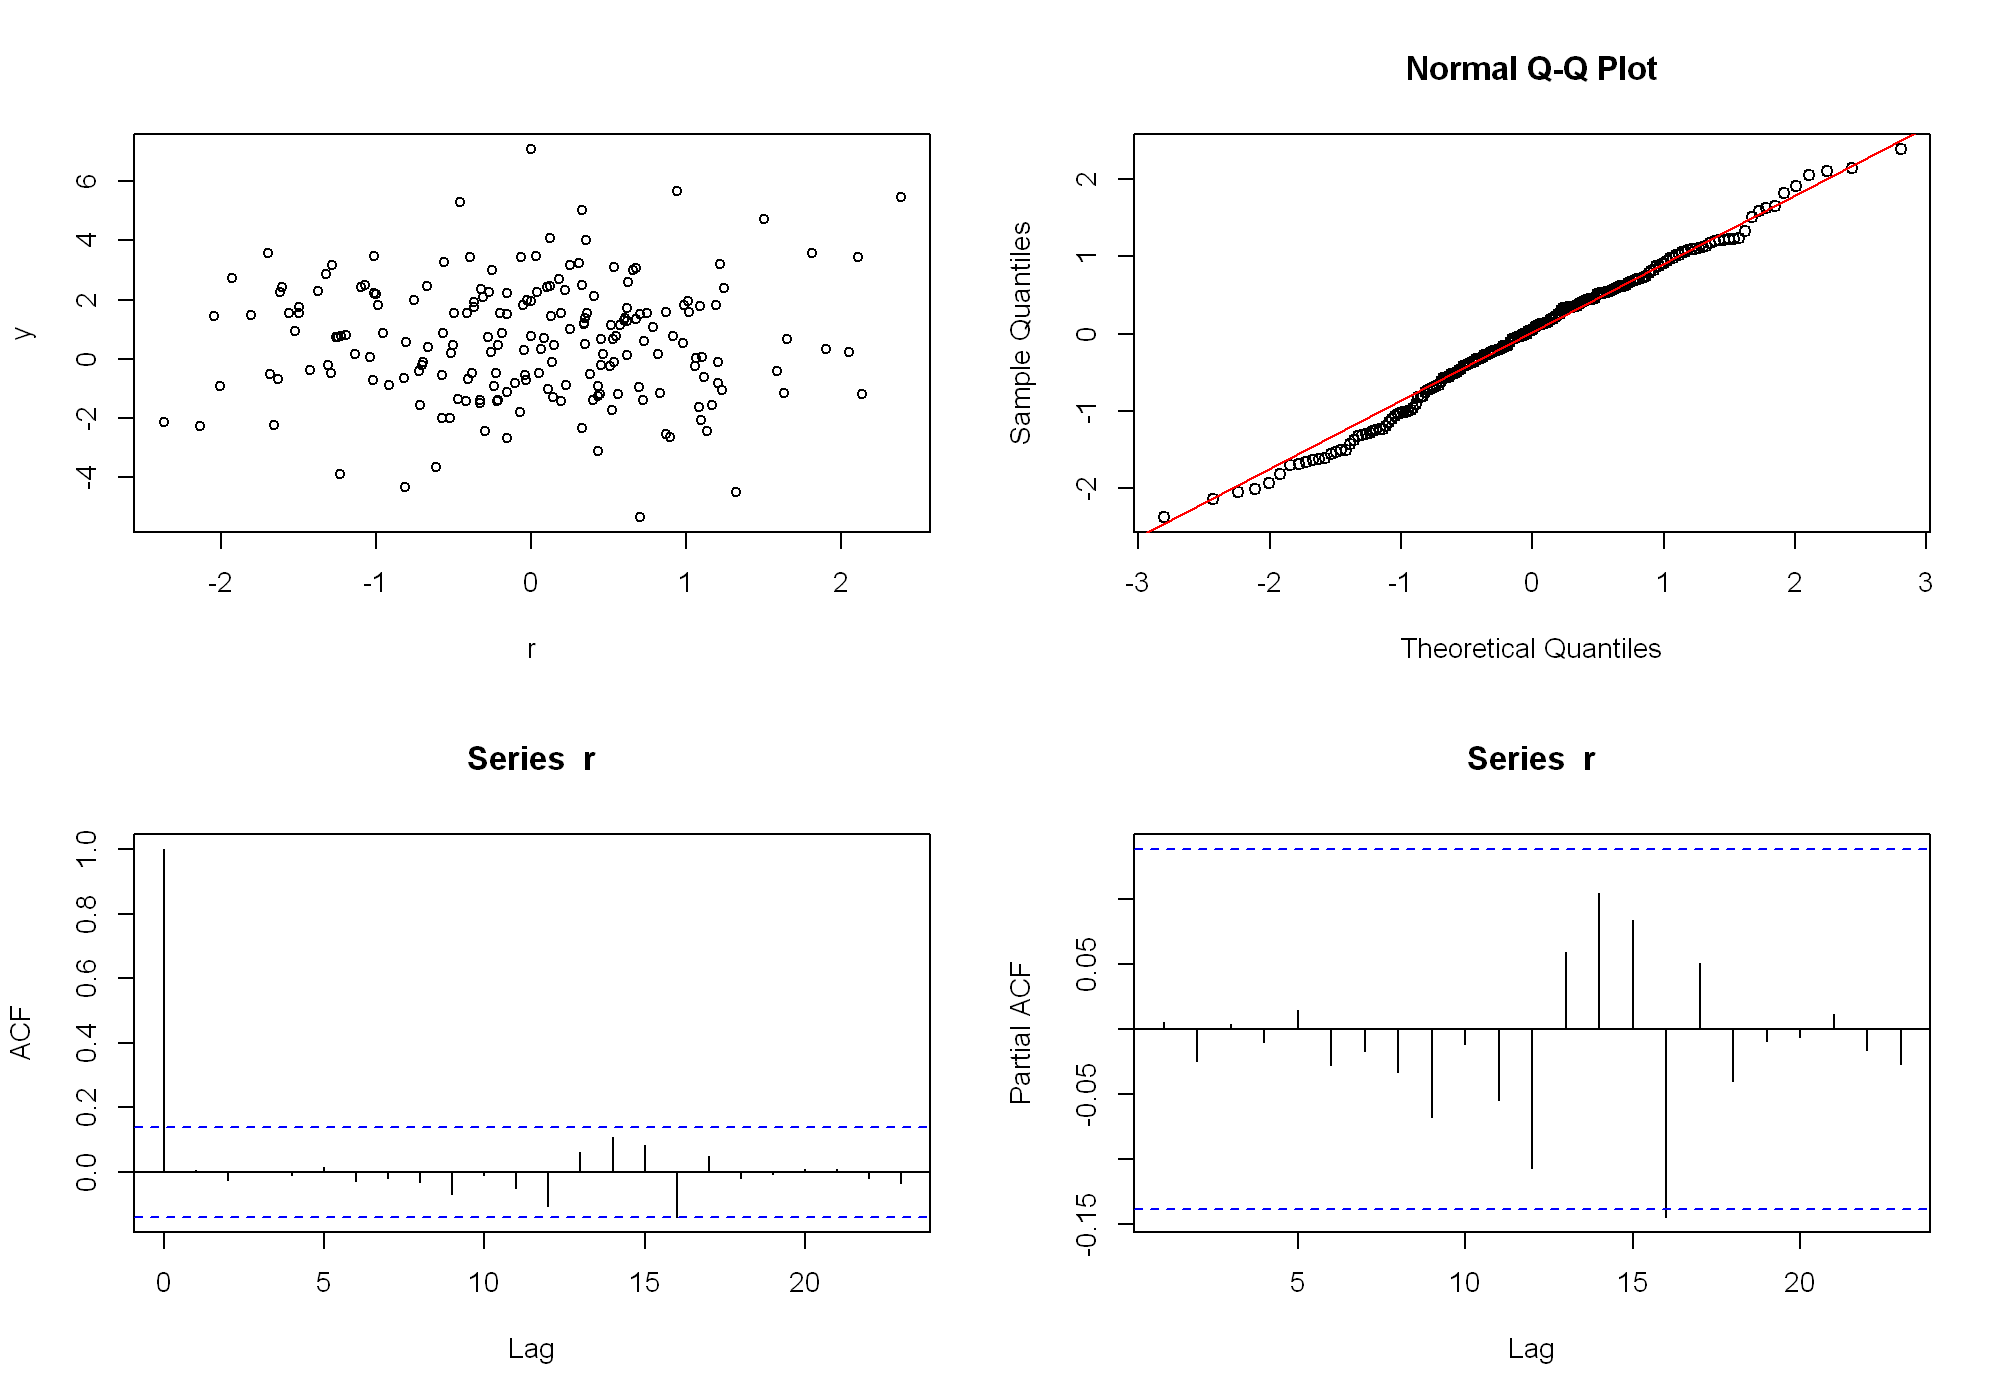

In [268]:
r <- na.omit(f2$residuals)
y <- ts-r
par(mfrow = c(2,1))
plot(r)
plot(ts,type="p")
lines(y,col="red")
par(mfrow = c(2,2))

plot(r,y,type="p",xy.labels = FALSE, xy.lines = FALSE)
qqnorm(r)
qqline(r,col="red")
acf(r)
pacf(r)


f2

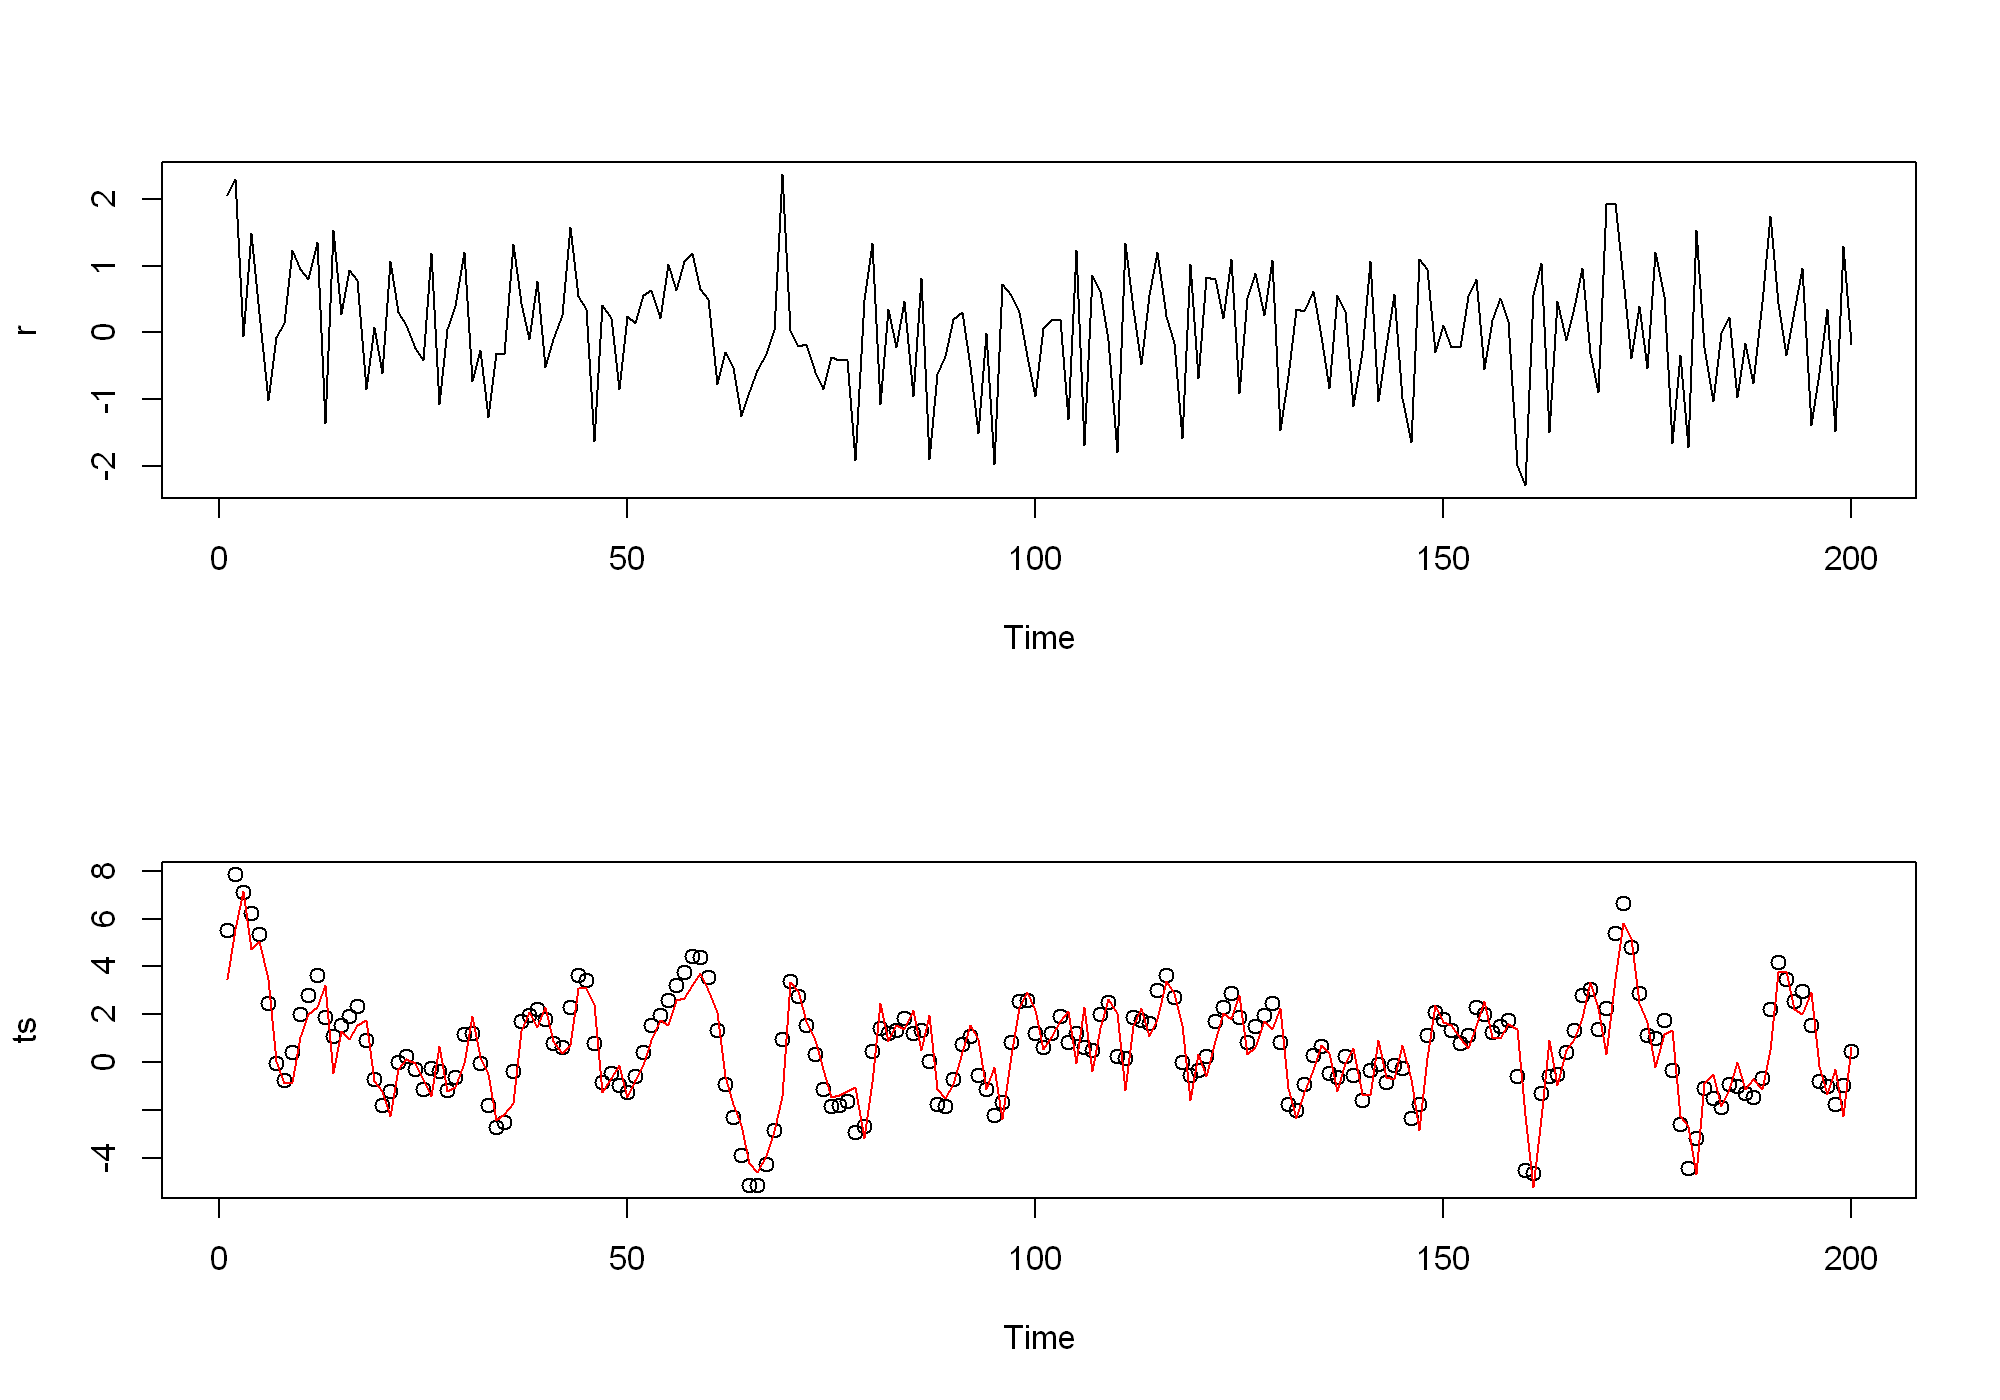

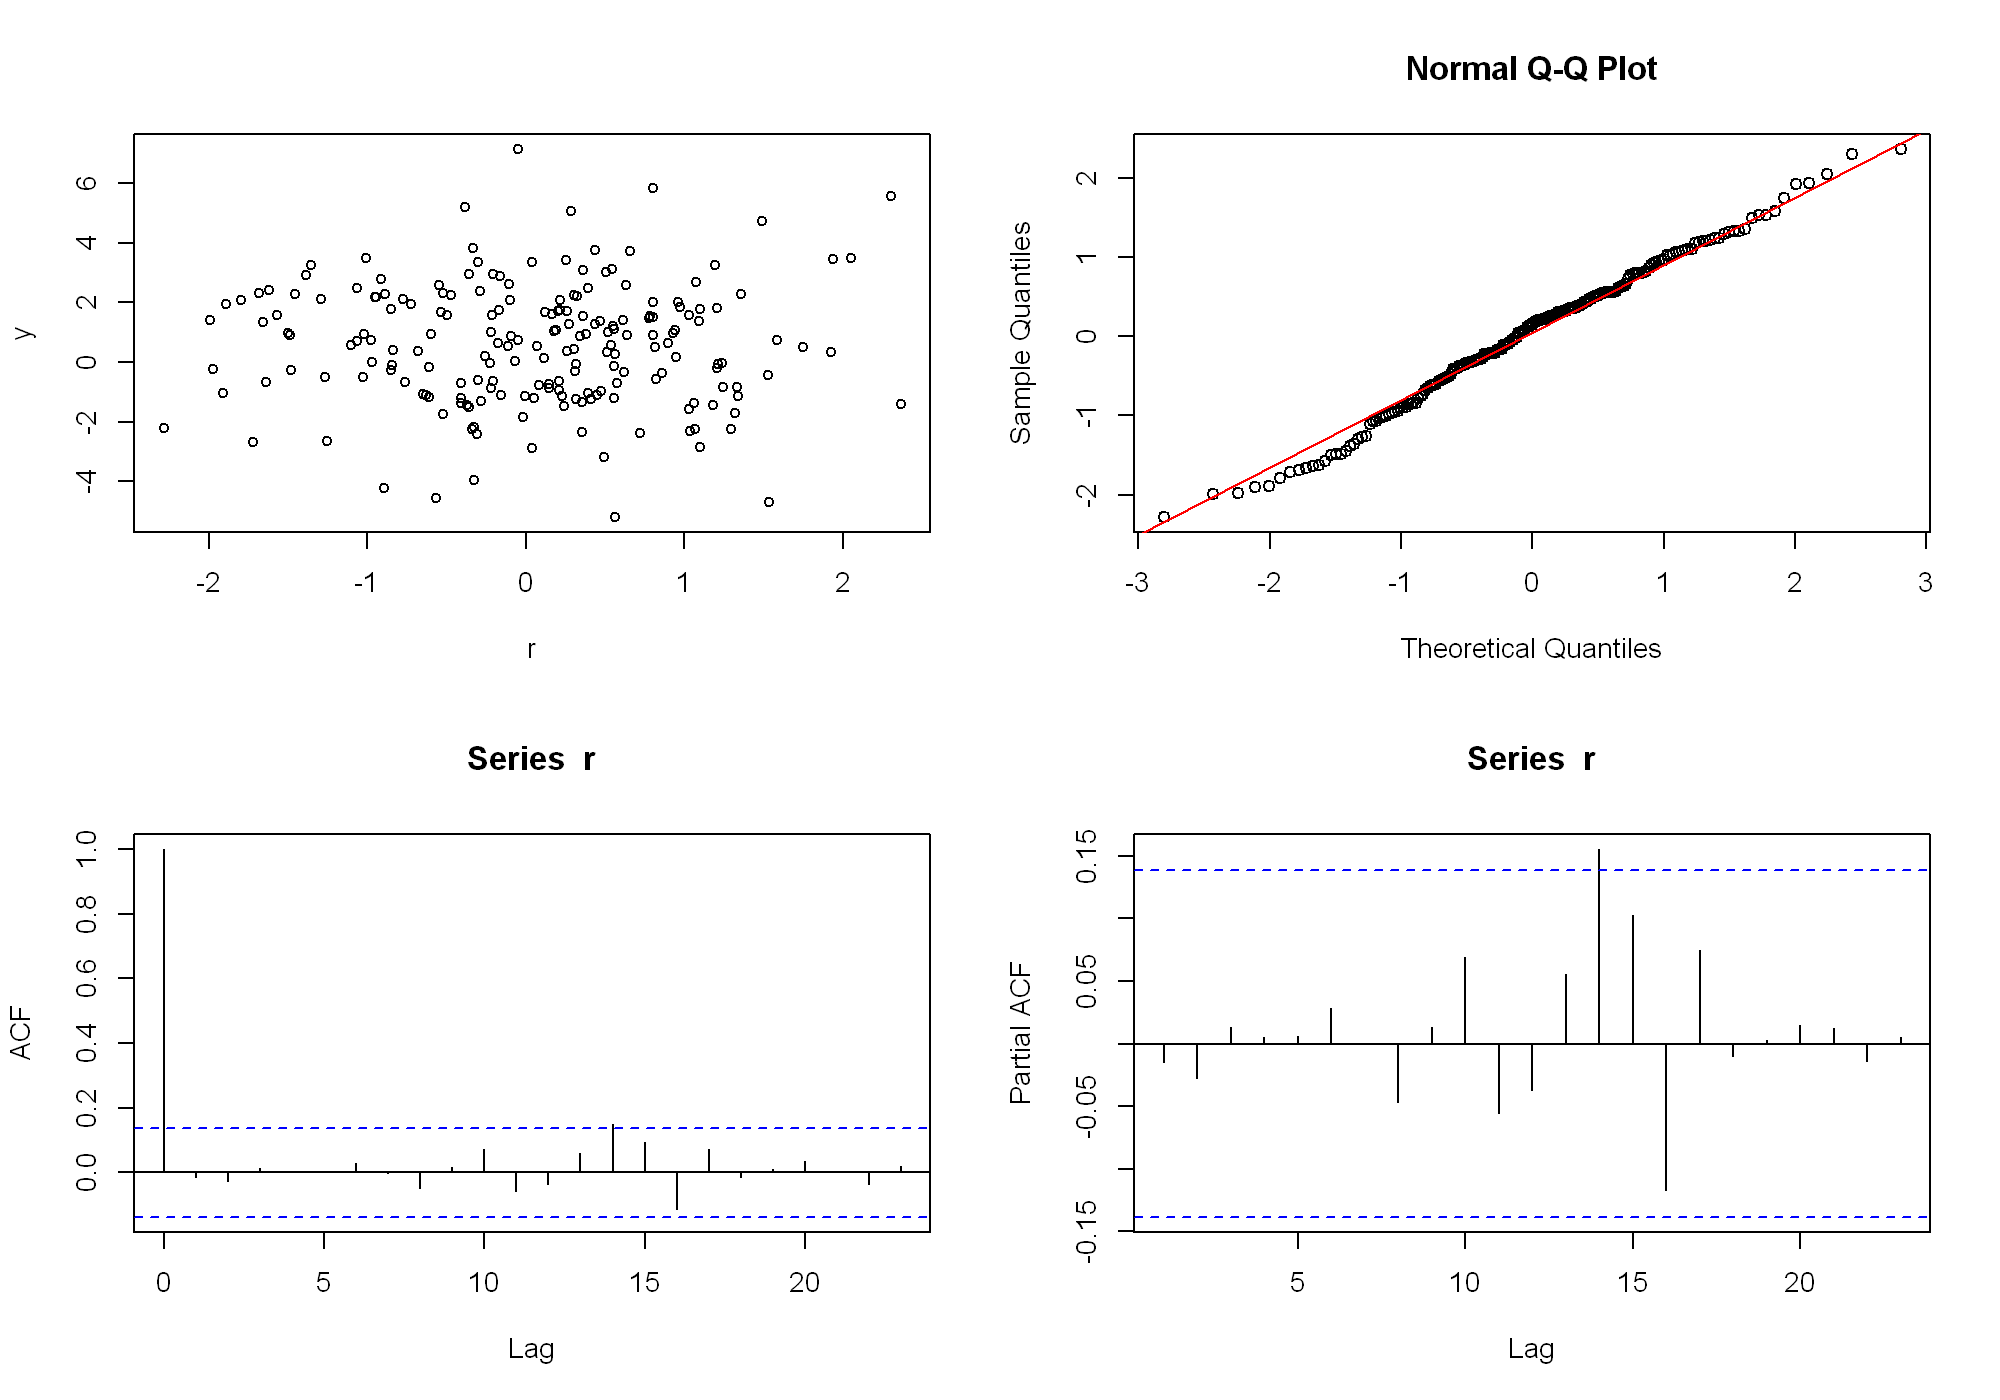

In [260]:
r <- na.omit(f3$residuals)
y <- ts-r
par(mfrow = c(2,1))
plot(r)
plot(ts,type="p")
lines(y,col="red")
par(mfrow = c(2,2))

plot(r,y,type="p",xy.labels = FALSE, xy.lines = FALSE)
qqnorm(r)
qqline(r,col="red")
acf(r)
pacf(r)


In [269]:
f3


Call:
arima(x = ts, order = c(3, 0, 3))

Coefficients:
         ar1      ar2      ar3     ma1      ma2      ma3  intercept
      1.5487  -0.5725  -0.0242  0.0099  -0.7678  -0.2413     0.5138
s.e.  0.4520   0.7660   0.3378  0.4527   0.1062   0.3582     0.0485

sigma^2 estimated as 0.8354:  log likelihood = -268.41,  aic = 552.82

In [262]:
library(forecast)

Warning message:
"package 'forecast' was built under R version 4.3.3"
Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



In [271]:
f4 <- auto.arima(ts)
f4
f3

Series: ts 
ARIMA(2,0,2) with non-zero mean 

Coefficients:
         ar1      ar2     ma1      ma2    mean
      1.5180  -0.6501  0.0260  -0.5697  0.6042
s.e.  0.1887   0.1179  0.2176   0.1903  0.2324

sigma^2 = 0.8969:  log likelihood = -271.72
AIC=555.45   AICc=555.88   BIC=575.24


Call:
arima(x = ts, order = c(3, 0, 3))

Coefficients:
         ar1      ar2      ar3     ma1      ma2      ma3  intercept
      1.5487  -0.5725  -0.0242  0.0099  -0.7678  -0.2413     0.5138
s.e.  0.4520   0.7660   0.3378  0.4527   0.1062   0.3582     0.0485

sigma^2 estimated as 0.8354:  log likelihood = -268.41,  aic = 552.82

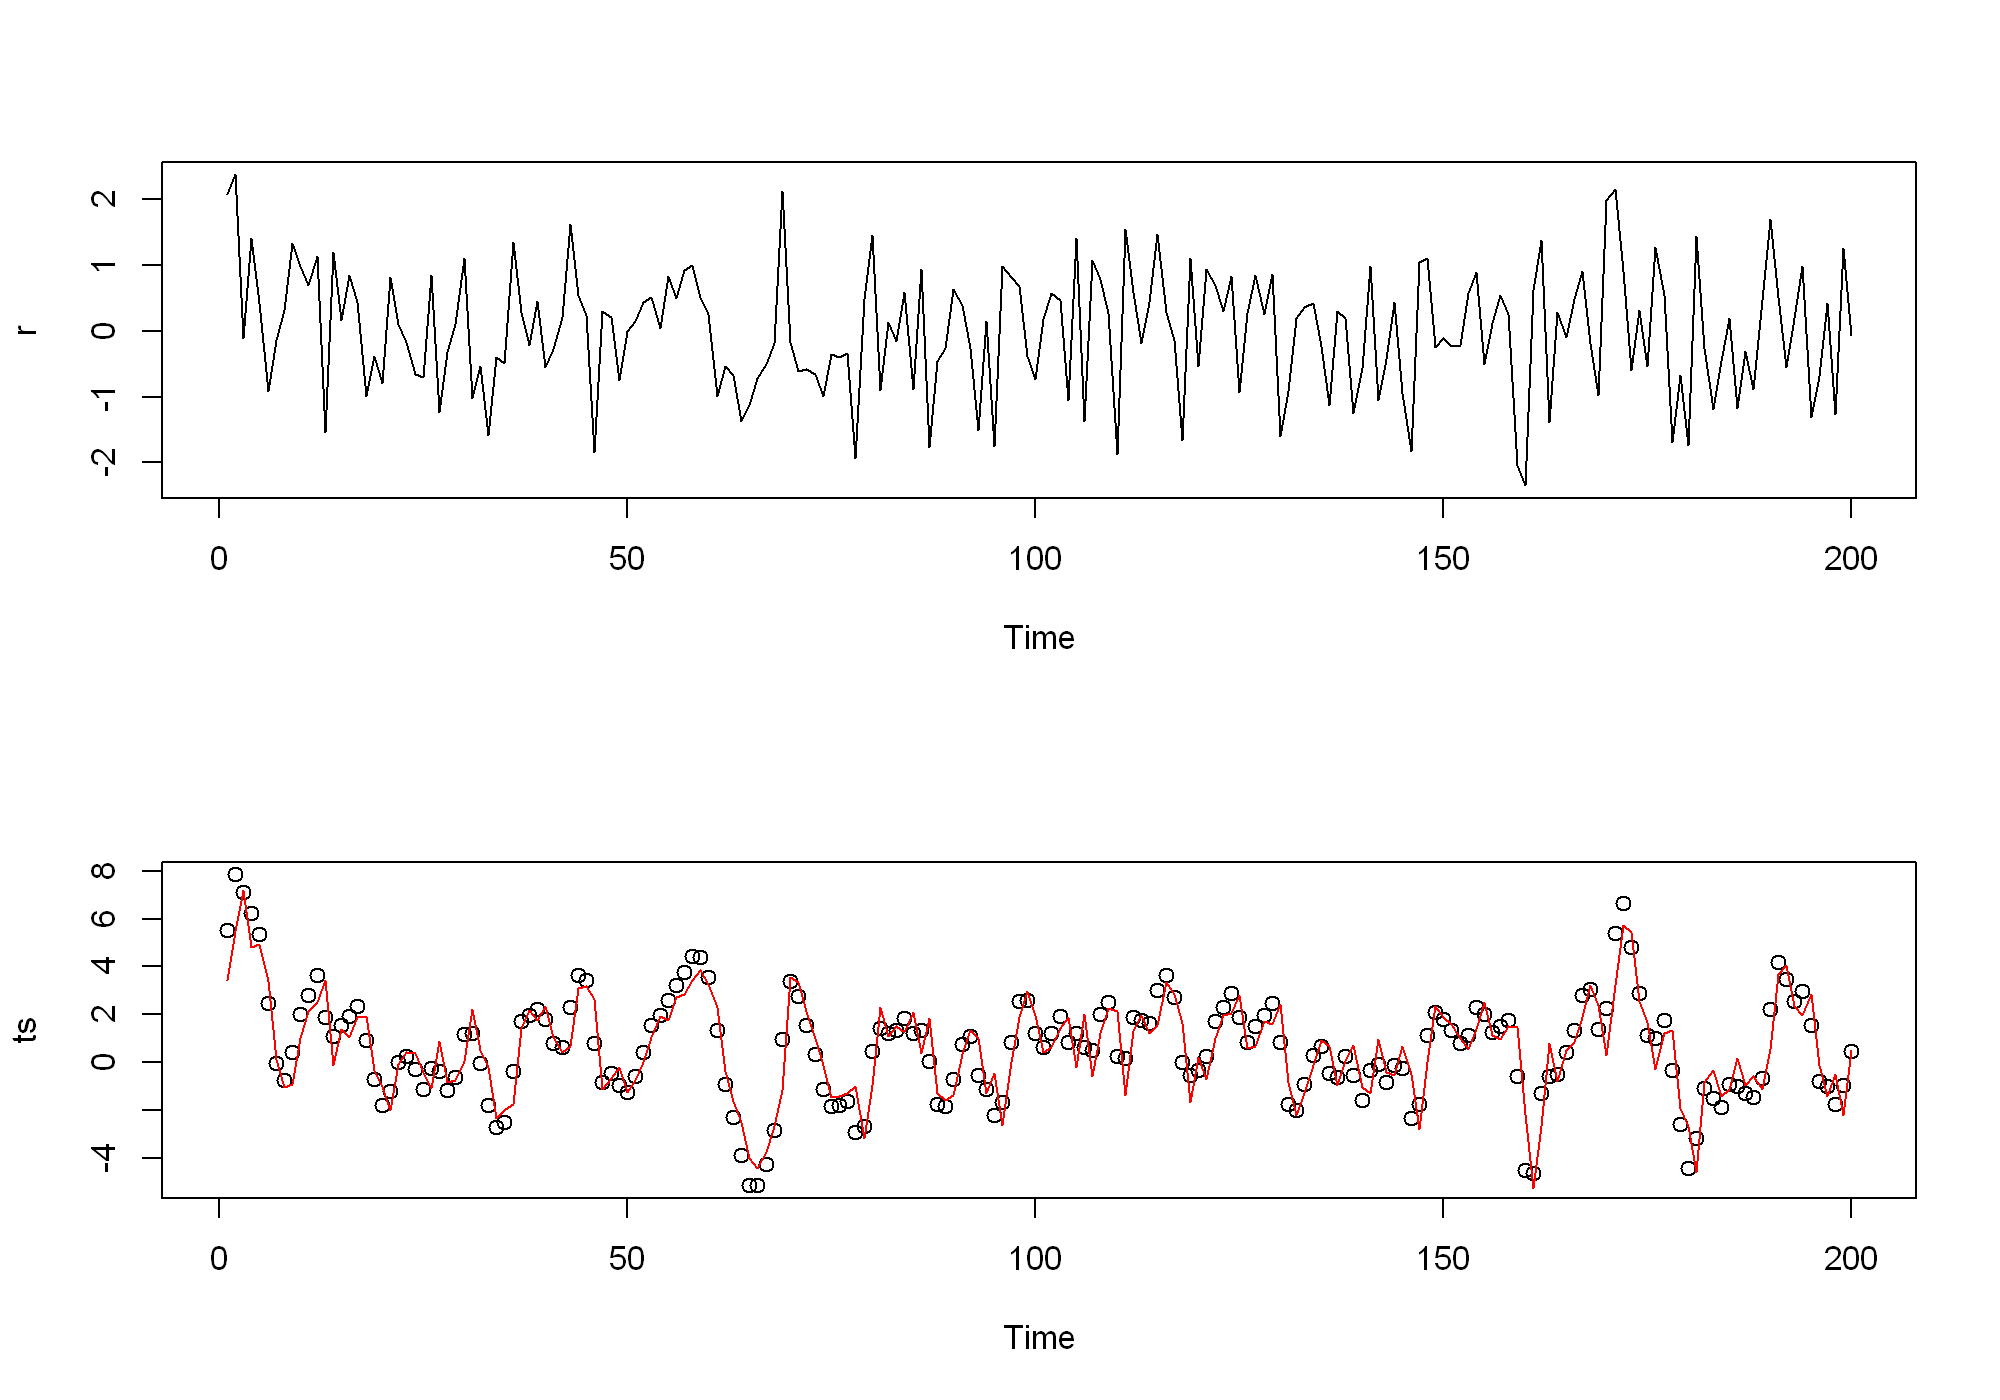

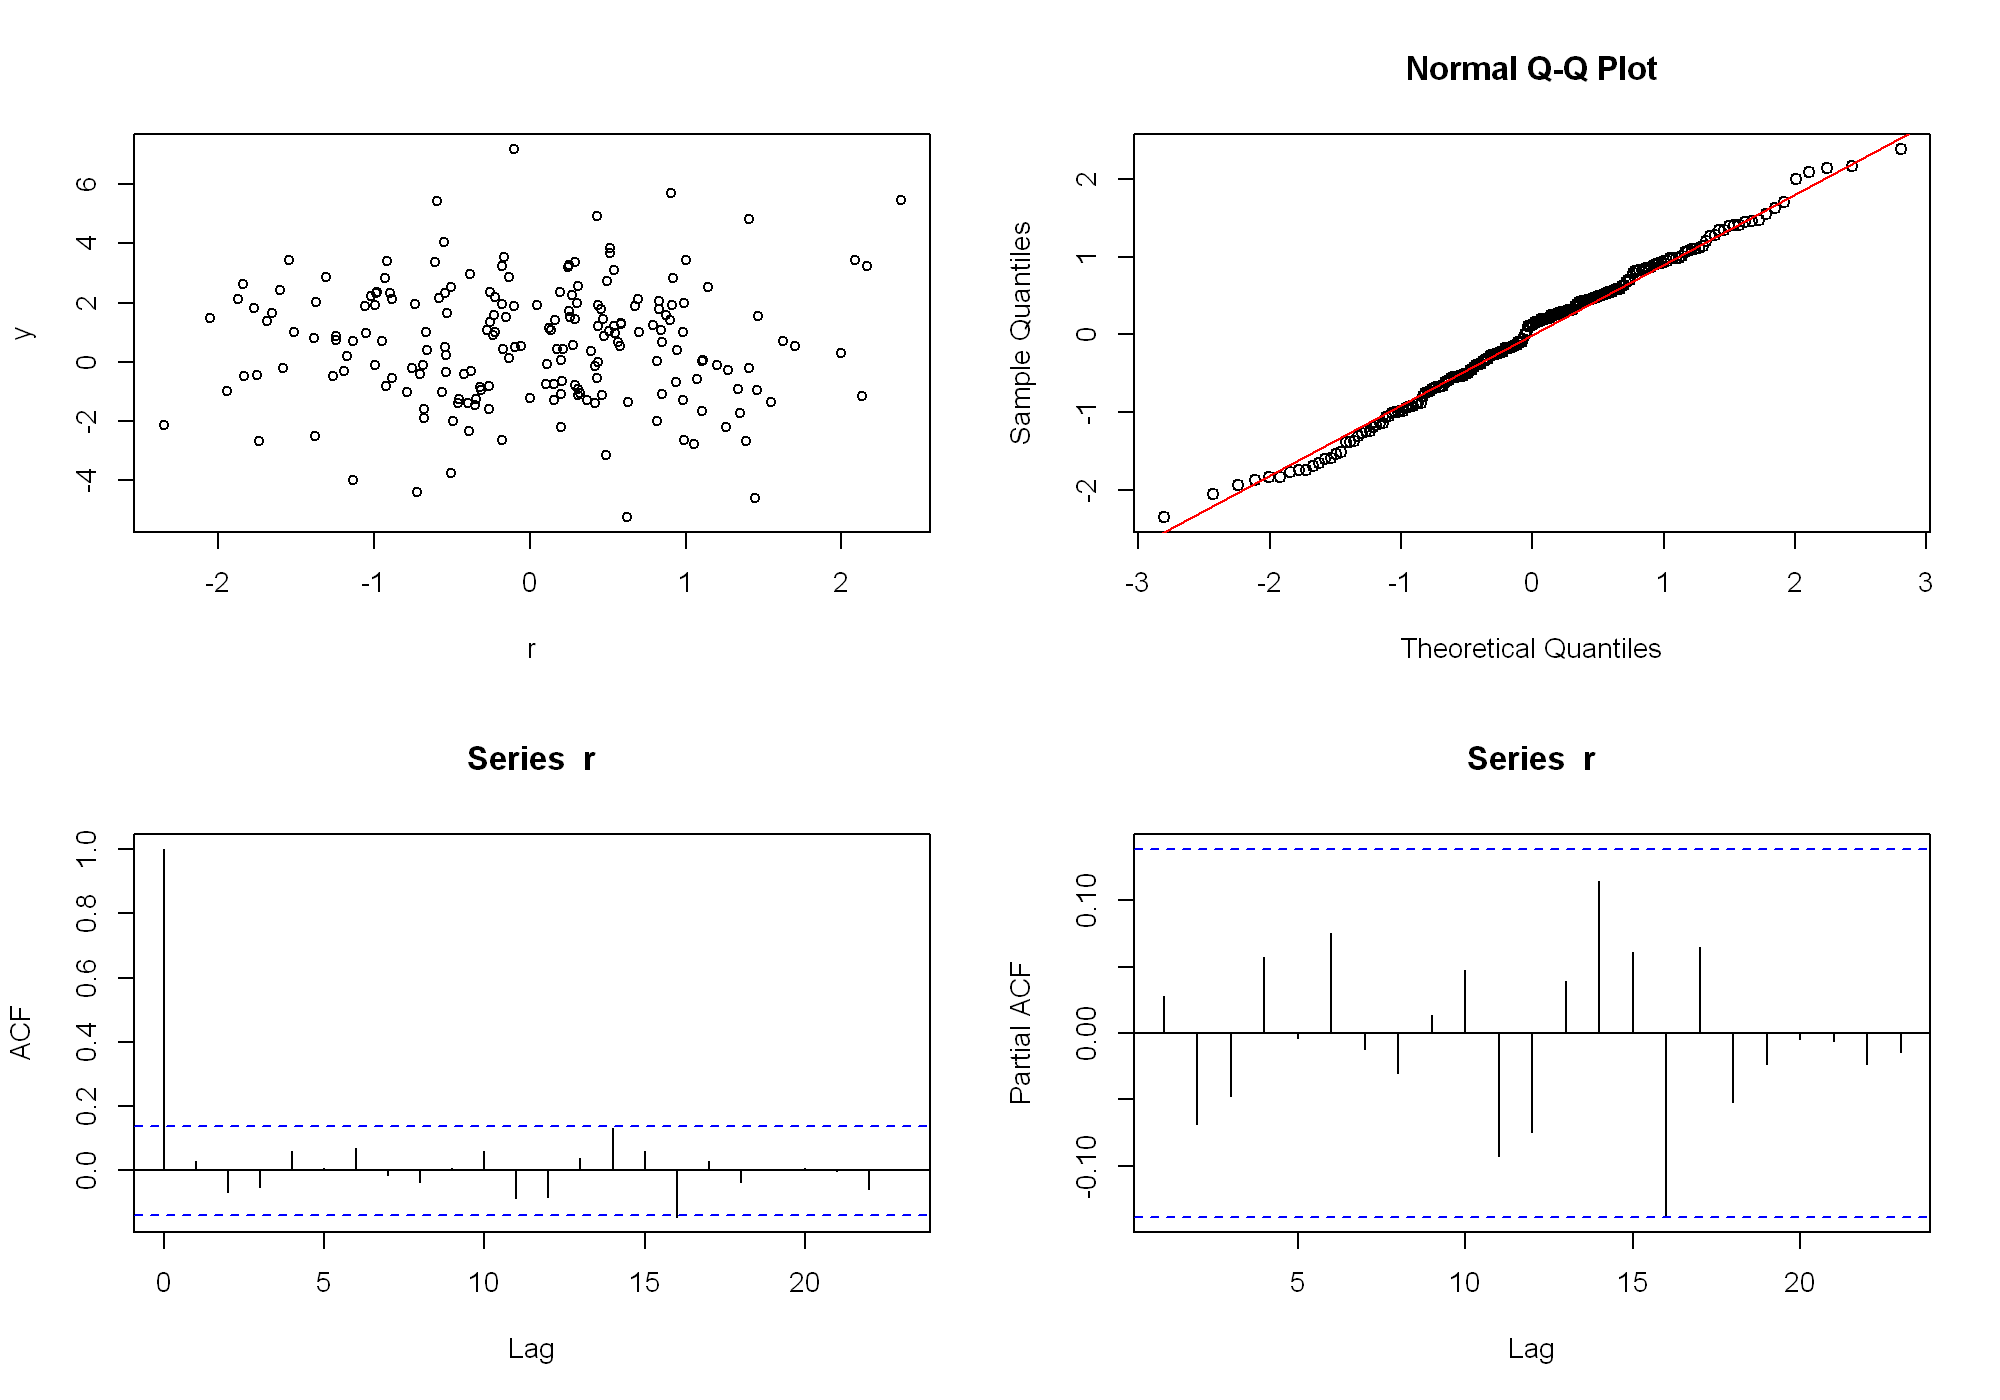

In [266]:
r <- na.omit(f4$residuals)
y <- ts-r
par(mfrow = c(2,1))
plot(r)
plot(ts,type="p")
lines(y,col="red")
par(mfrow = c(2,2))

plot(r,y,type="p",xy.labels = FALSE, xy.lines = FALSE)
qqnorm(r)
qqline(r,col="red")
acf(r)
pacf(r)
